In [ ]:
!pip install xgi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 23.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import xgi
import matplotlib.animation as animation
import numpy as np
from collections import defaultdict
from collections import Counter
from matplotlib.colors import LogNorm
from itertools import combinations, product
import gc
import collections

import os
import pickle
import gzip
from tqdm import tqdm
import multiprocessing

Mounted at /content/drive


In [ ]:
def AnimateEdgeSizes(H):

  # Extract edge sizes and timestamps
  edge_data = []
  for edge_id in H_coauth_dblp.edges:
      timestamp = H_coauth_dblp.edges[edge_id].get('timestamp')
      edge_size = H_coauth_dblp.edges.size[edge_id]  # Number of nodes in the hyperedge
      if timestamp is not None:
          edge_data.append((timestamp, edge_size))

  # Group edge sizes by timestamp (year)
  size_by_year = defaultdict(list)
  for timestamp, size in edge_data:
      size_by_year[timestamp].append(size)

  # Get sorted years and determine histogram parameters
  years = sorted(size_by_year.keys())
  all_sizes = [size for sizes in size_by_year.values() for size in sizes]
  max_size = max(all_sizes)
  min_size = min(all_sizes)

  # Create bins for consistent histogram across all years
  bins = np.arange(min_size, max_size + 2) - 0.5  # Centered bins for integer sizes

  # Set up the figure and axis
  fig, ax = plt.subplots(figsize=(12, 8))
  ax.set_xlim(min_size - 0.5, min(max_size + 0.5, 20))  # Limit x-axis for better visibility
  ax.set_xlabel('Edge Size (Number of Authors)', fontsize=12)
  ax.set_ylabel('Frequency', fontsize=12)
  ax.set_title('Distribution of Collaboration Sizes Over Time\ncoauth-DBLP Dataset', fontsize=14)
  ax.grid(True, alpha=0.3)

  # Initialize empty bar container
  bars = ax.bar([], [], alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

  # Text elements for displaying current year and statistics
  year_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, fontsize=14,
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
  stats_text = ax.text(0.02, 0.85, '', transform=ax.transAxes, fontsize=10,
                      verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

  # Create animation
  anim = animation.FuncAnimation(fig, animate, frames=len(years),
                             interval=1000, blit=False, repeat=True)

  # Display basic information
  print(f"Animation will show {len(years)} years from {min(years)} to {max(years)}")
  print(f"Total number of hyperedges: {len(edge_data)}")
  print(f"Edge size range: {min_size} to {max_size}")

  # Show the animation
  plt.tight_layout()
  plt.show()

  # Optional: Save animation as GIF (uncomment if needed)
  anim.save('edge_size_distribution_animation.gif', writer='pillow', fps=1)

  # Optional: Save animation as MP4 (uncomment if needed and ensure ffmpeg is installed)
  # anim.save('edge_size_distribution_animation.mp4', writer='ffmpeg', fps=1)

  return 0

def animate(frame):
    year = years[frame]
    sizes = size_by_year[year]

    # Calculate histogram
    hist, _ = np.histogram(sizes, bins=bins)

    # Clear previous bars
    ax.clear()

    # Create new bars
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bars = ax.bar(bin_centers, hist, alpha=0.7, color='steelblue',
                  edgecolor='black', linewidth=0.5, width=0.8)

    # Update axis properties
    ax.set_xlim(min_size - 0.5, min(max_size + 0.5, 20))
    ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 10)
    ax.set_xlabel('Edge Size (Number of Authors)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Collaboration Sizes Over Time\ncoauth-DBLP Dataset', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Update text displays
    year_text = ax.text(0.02, 0.98, f'Year: {year}', transform=ax.transAxes,
                       fontsize=14, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Calculate statistics
    mean_size = np.mean(sizes)
    median_size = np.median(sizes)
    total_edges = len(sizes)
    max_collab_size = max(sizes)

    stats_text = ax.text(0.02, 0.85,
                        f'Total Collaborations: {total_edges}\n'
                        f'Mean Size: {mean_size:.2f}\n'
                        f'Median Size: {median_size:.1f}\n'
                        f'Max Size: {max_collab_size}',
                        transform=ax.transAxes, fontsize=10,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    return bars

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def Components(H, name):

  component_lengths = [len(component) for component in xgi.connected_components(H)]
  max_length = max(component_lengths)

  if len(component_lengths) == 1:
    return (max_length, component_lengths)

  # Exclude the largest component
  filtered_component_lengths = [length for length in component_lengths if length != max_length]

  # Create figure and subplots
  fig, ax = plt.subplots(1, 1, figsize=(10,5))

  # Create histogram and get bin information
  hist, bins, patches = ax.hist(
      filtered_component_lengths,
      bins=range(min(filtered_component_lengths), max(filtered_component_lengths) + 2, 1), # Added +2 to include the last bin
      color="blue",
      edgecolor='black'
  )

  # Calculate bin centers for tick positions
  bin_centers = 0.5 * (bins[:-1] + bins[1:])

  # Set tick positions and labels
  ax.set_xticks(bin_centers)
  ax.set_xticklabels([str(int(b)) for b in bins[:-1]]) # Use bin start as label

  # Set font sizes for labels
  title_font_size = 18
  label_font_size = 16
  tick_font_size = 12
  legend_font_size = 12

  # Set tick parameters
  ax.tick_params(axis='both', which='major', labelsize=tick_font_size)

  ##ax.set_yscale('log');
  ax.set_xlabel("Component Length",fontsize=label_font_size)
  ax.set_ylabel("Frequency",fontsize=label_font_size);
  ax.set_title("Component Sizes for "+str(name)+" Data",fontsize=title_font_size)
  plt.show()

  return (max_length, component_lengths)

In [ ]:
def Extract_XtYt(H, timing = False):
  H_working = H.copy()

  # Initialize tracking variables
  iteration = 0
  isolated_nodes_per_iteration = []
  removed_edges_info = []

  # Store initial degrees of all nodes for efficient updates
  node_degrees = {}
  temp_degrees = H_working.nodes.degree.aslist(); i = 0
  for node in H_working.nodes:
      node_degrees[node] = temp_degrees[i]
      i += 1

  print("Starting iterative edge removal process...")
  print(f"Initial hypergraph: {H_working.num_nodes} nodes, {H_working.num_edges} edges")
  print(f"Computed initial degrees for {len(node_degrees)} nodes")

  # Find all edges with valid timestamps
  edges_with_timestamps = []
  for edge_id in H_working.edges:
      timestamp = H_working.edges[edge_id].get('timestamp')
      if timestamp is not None:
          edge_size = H_working.edges.size[edge_id]
          edges_with_timestamps.append((edge_id, timestamp, edge_size))
  # Sort by timestamps (ascending) then iterate backwards
  edges_with_timestamps.sort(key=lambda x: x[1])

  while H_working.num_edges > 0:
      # Find the latest timestamp (last element since sorted)
      latest_timestamp = edges_with_timestamps[-1][1]

      # Find all edges with the latest timestamp by scanning backwards
      latest_edges = []
      i = len(edges_with_timestamps) - 1
      while i >= 0 and edges_with_timestamps[i][1] == latest_timestamp:
          latest_edges.append(edges_with_timestamps[i])
          i -= 1
      # Sort by edge size
      latest_edges.sort(key=lambda x: x[2])

      # Remove the latest edges from edges_with_timestamps (they're at the end)
      edges_with_timestamps = edges_with_timestamps[:i+1]

      while len(latest_edges) > 0:

        # Find the largest edge among those with the latest timestamp
        # Breaking ties arbitrarily by taking the first one after sorting by edge_id
        largest_edge = latest_edges[-1]
        edge_id_to_remove, timestamp, edge_size = largest_edge
        latest_edges.remove(largest_edge)

        # Get the nodes in the edge before removal
        nodes_in_edge = list(H_working.edges.members(edge_id_to_remove))

        # Remove the edge
        H_working.remove_edge(edge_id_to_remove)

        for node in nodes_in_edge:
          if node in node_degrees:
              node_degrees[node] -= 1

        # Check how many nodes became isolated (degree 0)
        isolated_count = 0
        isolated_nodes = []

        for node in nodes_in_edge:
          if node in node_degrees:  # Check if node still exists in our degree tracking
              if node_degrees[node] == 0:
                  isolated_count += 1
                  isolated_nodes.append(node)

        # Record the results
        isolated_nodes_per_iteration.append(isolated_count)
        removed_edges_info.append({
          'iteration': iteration,
          'edge_id': edge_id_to_remove,
          'timestamp': timestamp,
          'edge_size': edge_size,
          'isolated_nodes': isolated_count,
          'nodes_in_edge': nodes_in_edge,
          'isolated_node_ids': isolated_nodes
        })

        # Print progress
        if (iteration % 100 == 0 or iteration < 10) and (timing == True):
          print(f"Iteration {iteration}: Removed edge {edge_id_to_remove} "
                f"(timestamp: {timestamp}, size: {edge_size}), "
                f"isolated nodes: {isolated_count}")

        iteration += 1

        # Optional: Break after a certain number of iterations to avoid long runs
        #if iteration >= 1000:  # Adjust this limit as needed
        #  print(f"Stopping after {iteration} iterations...")
        #  break

  print(f"\nCompleted {iteration} iterations")
  print(f"Final hypergraph: {H_working.num_nodes} nodes, {H_working.num_edges} edges")

  # Analysis of results
  print("\n=== ANALYSIS RESULTS ===")
  print(f"Total edges removed: {len(removed_edges_info)}")
  print(f"Total isolated nodes across all iterations: {sum(isolated_nodes_per_iteration)}")
  print(f"Average isolated nodes per iteration: {np.mean(isolated_nodes_per_iteration):.2f}")
  print(f"Maximum isolated nodes in single iteration: {max(isolated_nodes_per_iteration)}")

  # Find iterations with highest isolation
  max_isolation = max(isolated_nodes_per_iteration)
  max_isolation_iterations = [i for i, count in enumerate(isolated_nodes_per_iteration) if count == max_isolation]

  print(f"\nIterations with maximum isolation ({max_isolation} nodes):")
  for iter_idx in max_isolation_iterations[:5]:  # Show first 5
      info = removed_edges_info[iter_idx]
      print(f"  Iteration {iter_idx}: Edge {info['edge_id']} "
            f"(timestamp: {info['timestamp']}, size: {info['edge_size']})")

  # Visualize the results
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

  # Plot 1: Isolated nodes per iteration
  ax1.plot(range(len(isolated_nodes_per_iteration)), isolated_nodes_per_iteration,
           'b-', alpha=0.7, linewidth=1)
  ax1.fill_between(range(len(isolated_nodes_per_iteration)), isolated_nodes_per_iteration,
                   alpha=0.3, color='blue')
  ax1.set_xlabel('Iteration')
  ax1.set_ylabel('Number of Isolated Nodes')
  ax1.set_title('Nodes Becoming Isolated After Each Edge Removal')
  ax1.grid(True, alpha=0.3)

  # Plot 2: Cumulative isolated nodes
  cumulative_isolated = np.cumsum(isolated_nodes_per_iteration)
  ax2.plot(range(len(cumulative_isolated)), cumulative_isolated,
           'r-', linewidth=2)
  ax2.set_xlabel('Iteration')
  ax2.set_ylabel('Cumulative Isolated Nodes')
  ax2.set_title('Cumulative Number of Isolated Nodes')
  ax2.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

  # Summary statistics
  print(f"\n=== SUMMARY STATISTICS ===")
  print(f"Iterations with 0 isolated nodes: {isolated_nodes_per_iteration.count(0)}")
  print(f"Iterations with 1 isolated node: {isolated_nodes_per_iteration.count(1)}")
  print(f"Iterations with >1 isolated nodes: {sum(1 for x in isolated_nodes_per_iteration if x > 1)}")

  # Show edge size distribution of removed edges
  edge_sizes = [info['edge_size'] for info in removed_edges_info]
  print(f"\nRemoved edge sizes - Min: {min(edge_sizes)}, Max: {max(edge_sizes)}, Mean: {np.mean(edge_sizes):.2f}")

  return removed_edges_info

Streaming output truncated to the last 5000 lines.
Iteration 2373000: Removed edge 1850682 (timestamp: 2002, size: 6), isolated nodes: 3
Iteration 2373100: Removed edge 2063562 (timestamp: 2002, size: 6), isolated nodes: 4
Iteration 2373200: Removed edge 2272102 (timestamp: 2002, size: 6), isolated nodes: 0
Iteration 2373300: Removed edge 2510239 (timestamp: 2002, size: 6), isolated nodes: 4
Iteration 2373400: Removed edge 2716011 (timestamp: 2002, size: 6), isolated nodes: 1
Iteration 2373500: Removed edge 2934863 (timestamp: 2002, size: 6), isolated nodes: 3
Iteration 2373600: Removed edge 3052550 (timestamp: 2002, size: 6), isolated nodes: 6
Iteration 2373700: Removed edge 3196331 (timestamp: 2002, size: 6), isolated nodes: 1
Iteration 2373800: Removed edge 3402177 (timestamp: 2002, size: 6), isolated nodes: 4
Iteration 2373900: Removed edge 3620359 (timestamp: 2002, size: 6), isolated nodes: 5
Iteration 2374000: Removed edge 115884 (timestamp: 2002, size: 5), isolated nodes: 2
Iter

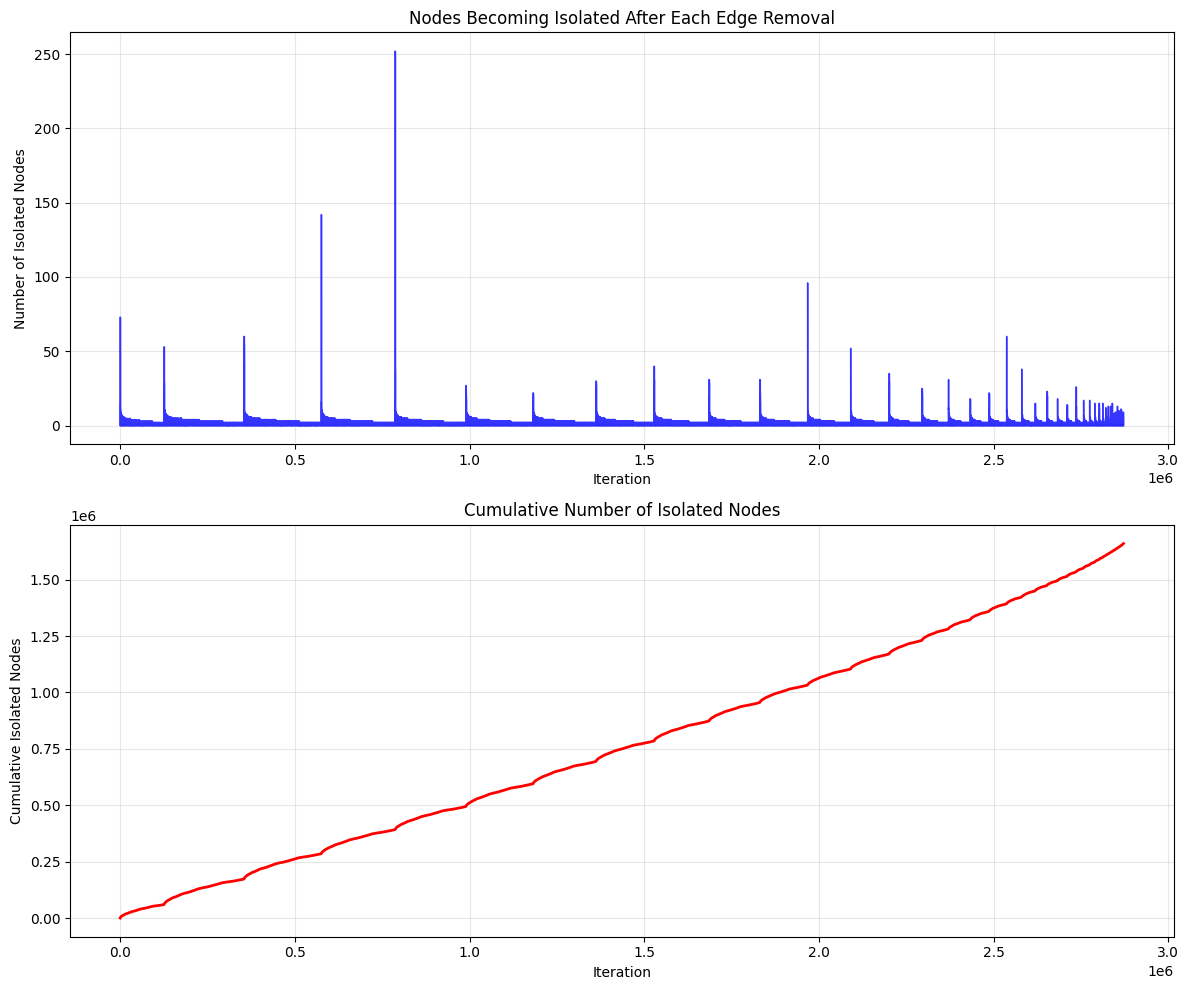


=== SUMMARY STATISTICS ===
Iterations with 0 isolated nodes: 1769221
Iterations with 1 isolated node: 750054
Iterations with >1 isolated nodes: 352453

Removed edge sizes - Min: 2, Max: 280, Mean: 3.26
Saved /content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/coauth-dblp.pkl


In [ ]:
def process_dataset(name, timing=False):
    filename = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/' + str(name) + '.pkl'
    # Check if current file already exists, if it does exist we do not
    # want to waste time running it again
    ##if os.path.exists(filename):
    ##    print(f"File {filename} already exists. Skipping...")
    ##    return

    H = xgi.load_xgi_data(name)
    H = H.cleanup(multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True)

    extracted_info = Extract_XtYt(H, timing=timing)
    # Pickle and save the output
    with gzip.open(filename, 'wb') as f:
        pickle.dump(extracted_info, f)
    print(f"Saved {filename}")


names = []#['congress-bills','threads-ask-ubuntu','threads-math-sx','tags-ask-ubuntu','tags-math-sx',
         #'coauth-dblp','coauth-MAG-history','coauth-MAG-geology']
        #['congress-bills', 'email-Enron', 'email-EU', 'threads-ask-ubuntu', 'threads-math-sx',
         #'contact-high-school', 'contact-primary-school', 'hospital-lyon', 'malawi-village',
         #'science-gallery', 'SFHH-conference', 'hypertext-conference', 'InVS13', 'InVS15',
         #'tags-ask-ubuntu', 'tags-math-sx',
         #'coauth-dblp', 'coauth-MAG-history', 'coauth-MAG-geology']#

# Use multiprocessing Pool to parallelize the processing
#if __name__ == '__main__': # This is important for multiprocessing in notebooks
#    with multiprocessing.Pool(processes=8) as pool:
#        list(tqdm(pool.imap(process_dataset, names), total=len(names)))

process_dataset('coauth-dblp',timing=True)

In [ ]:
def Plot_Yt(Yt, name):
  # Create figure and subplots
  fig, ax = plt.subplots(1, 1, figsize=(10,5))
  #ax = plt.subplot(111)
  ax.hist(
      Yt,
      bins= np.arange(min(Yt) - 0.5, max(Yt) + 1.5, 1),
      color="blue",
      edgecolor='black'
  )
  # Set font sizes for labels
  title_font_size = 18
  label_font_size = 16
  tick_font_size = 12
  legend_font_size = 12

  # Set tick parameters
  ax.tick_params(axis='both', which='major', labelsize=tick_font_size)

  ax.set_yscale('log');
  ax.set_xlabel(r"Hyperedge size ($Y_t$)",fontsize=label_font_size)
  ax.set_ylabel("Frequency",fontsize=label_font_size);
  ax.set_title("Aggregated "+name+" Hyperedge Size Distribution",fontsize=title_font_size)
  plt.show()

  return 0

In [ ]:
def Plot_Xt(Xt, name):
  # Create figure and subplots
  fig, ax = plt.subplots(1, 1, figsize=(10,5))
  #ax = plt.subplot(111)
  ax.hist(
      Xt,
      bins= np.arange(min(Xt) - 0.5, max(Xt) + 1.5, 1),
      color="blue",
      edgecolor='black'
  )
  # Set font sizes for labels
  title_font_size = 18
  label_font_size = 16
  tick_font_size = 12
  legend_font_size = 12

  # Set tick parameters
  ax.tick_params(axis='both', which='major', labelsize=tick_font_size)

  ax.set_yscale('log');
  ax.set_xlabel(r"Nodes to be added ($X_t$)",fontsize=label_font_size)
  ax.set_ylabel("Frequency",fontsize=label_font_size);
  ax.set_title("Aggregated " + name + r" $X_t$ Distribution",fontsize=title_font_size)
  plt.show()

  return 0

In [ ]:
def frequency_colored_scatter(Xt, Yt, s=100, alpha=0.7, colormap='viridis'):
    """
    Create a scatter plot where points are colored based on their frequency

    Parameters:
    x_data, y_data: lists or arrays of data points
    s: marker size
    alpha: transparency
    colormap: colormap for frequency coloring
    """

    # Count frequency of each (x, y) coordinate pair
    coordinates = list(zip(Xt, Yt))
    coord_counts = Counter(coordinates)

    # Get unique coordinates and their frequencies
    unique_coords = list(coord_counts.keys())
    frequencies = list(coord_counts.values())

    # Separate x and y coordinates
    unique_x = [coord[0] for coord in unique_coords]
    unique_y = [coord[1] for coord in unique_coords]

    return unique_x, unique_y, frequencies

def PlotJoint_XtYt(Xt, Yt, name):
  # Create the frequency-colored scatter plot
  plt.figure(figsize=(15, 5))

  # Method 1: Basic frequency-colored scatter plot with log scale
  plt.subplot(1, 1, 1)
  unique_x, unique_y, frequencies = frequency_colored_scatter(Yt, Xt)

  scatter = plt.scatter(unique_x, unique_y, c=frequencies, s=25,
                       cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.5,
                       norm=LogNorm())
  plt.colorbar(scatter, label='Frequency (log scale)')
  plt.title(r'$Y_t,X_t$ Joint Distribution for ' + name)
  plt.xlabel(r'$Y_t$ (Hyperedge Size)')
  plt.ylabel(r'$X_t$ (Isolated Nodes)')
  plt.grid(True, alpha=0.3)

  return 0

In [ ]:
def DegreeDist(H, name):
    list_of_nodes_degrees = H.nodes.degree.aslist()
    degree_counts = Counter(list_of_nodes_degrees)

    # Get degrees and their frequencies
    degrees = np.array(list(degree_counts.keys()))
    frequencies = np.array(list(degree_counts.values()))

    # Sort by degree
    sorted_indices = np.argsort(degrees)
    degrees = degrees[sorted_indices]
    frequencies = frequencies[sorted_indices]

    # Create figure and subplots
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # Plot on a log-log scale
    ax.loglog(degrees, frequencies, 'o', markersize=5, color="blue", alpha=0.7)

    # Set font sizes for labels
    title_font_size = 18
    label_font_size = 16
    tick_font_size = 12

    # Set tick parameters
    ax.tick_params(axis='both', which='major', labelsize=tick_font_size)

    ax.set_xlabel("Node Degree", fontsize=label_font_size)
    ax.set_ylabel("Frequency", fontsize=label_font_size)
    ax.set_title("Hyperdegree Distribution for " + str(name) + " Data", fontsize=title_font_size)
    #ax.grid(True, which="both", ls="--", alpha=0.5)

    ax.grid(True, which='major', linestyle='-', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)

    plt.show()

    return degree_counts, np.mean(list_of_nodes_degrees)

In [ ]:
def Get_Simpliciality_SF(filename, processed_filename = None, minDim = 2, maxDim = np.inf):
  """
  Input: filename = string file name to load hypergraph
         processed_filename = string file name to save data to
         minDim = minimum simplex size to consider. Simplices below this
                  dimension are disregarded. Simplices equal to this dimension
                  are automatically downward closed and now counted.
         maxDim = maximum simplex dimension to consider. Used to
                  reduce computational complexity for large hypergraphs
                  with high cardinality edges.
  Return: SimplicialFraction = ratio of downward-closed hyperedges to
                               the total number of hyperedges
          Lengths = dictionary keeping track of the number of simplices of
                    each dimension which are downward closed.
  Description: To compute the simplicial fraction we take a dynamic
  programming approach. We first sort the edges by ascending length.
  Then, to check if a simplex e is downward closed it is sufficient to
  check if its |e|-1 sized subsets belong to H and are downward closed.
  """
  if type(filename) == dict:
    H = filename
  else:
    # Load data from input filename
    with gzip.open(filename, 'rb') as f:
      try:
        with gzip.open(filename, 'rb') as f:
          H = pickle.load(f)[0]
      except Exception as e:
        print(f"Error loading file: {filename}")
        return -1

  # Create a list of (key, set) tuples sorted by ascending set length
  sorted_items = sorted(H.items(), key=lambda item: len(item[1]), reverse=False)

  # Create a new dictionary with keys 0, 1, 2, ... corresponding to sorted sets
  H = {i: tuple(sorted(item[1])) for i, item in enumerate(sorted_items)}

  # Initialize dict that keeps track of edges in H, as well as whether
  # or not they are downward closed (True or False).
  IsSimplex = {e: True for e in H.values()}

  # Keep track of nodes which are downward closed and total number of
  # hyperedges with |e| > minDim (respectively)
  SimplexCount = 0
  CandidateCount = 0
  E = set()

  # Each timestep represents the addition of a single hyperedge
  for t in tqdm(range(len(H))):
    # To reduce memory overusage we cleanup every so often
    if t > 0 and t % 500000 == 0:
      gc.collect()

    # If the hyperedge is below the minimum size we discard it from consideration.
    # If hyperedge is at minimum size it is automatically a simplex, and so it is
    # disregarded from simpliciality computation
    e = H[t]

    if (len(e) <= minDim) or (len(e) > maxDim) or (e in E):
      continue

    # By default increase simplex and candidate counts by 1.
    SimplexCount += 1; CandidateCount += 1;
    E.add(e)

    # Iterate over the subsets of e of size |e|-1. e is downward closed
    # iff its |e|-1 subsets belong to the hypergraph, and are all downward
    # closed themselves.
    for face in combinations(e, len(e)-1):
      if (face not in IsSimplex) or (not IsSimplex[face]):
        # Since a subset is not a simplex, e is not a simplex
        IsSimplex[e] = False; SimplexCount -= 1
        break

  # Record simplicial fraction, as well as get a dictionary which
  # records the number of edges of each size which are downward closed.
  SimplicialFraction = SimplexCount / CandidateCount
  Lengths = [len(e) for e in IsSimplex if (IsSimplex[e] and len(e) > minDim and len(e) <= maxDim)]
  Lengths = collections.Counter(Lengths)

  # Pickle and save the output
  Data = [SimplicialFraction, Lengths]
  if processed_filename != None:
    with gzip.open(processed_filename, 'wb') as f:
      pickle.dump(Data, f)

    return Data

  else:
    return Data

---
## Collaboration Data:
* `coauth-dblp`
* `coauth-MAG-geology`
* `coauth-MAG-history`

In [ ]:
name = 'coauth-dblp'
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_ = DegreeDist(H, name)

KeyboardInterrupt: 

Removing singletons
The hypergraph has 903973 nodes and 965036 timestamped hyperedges
The hypergraph has 834152 unique hyperedges
Number of components: 1
Size of largest component: 903973


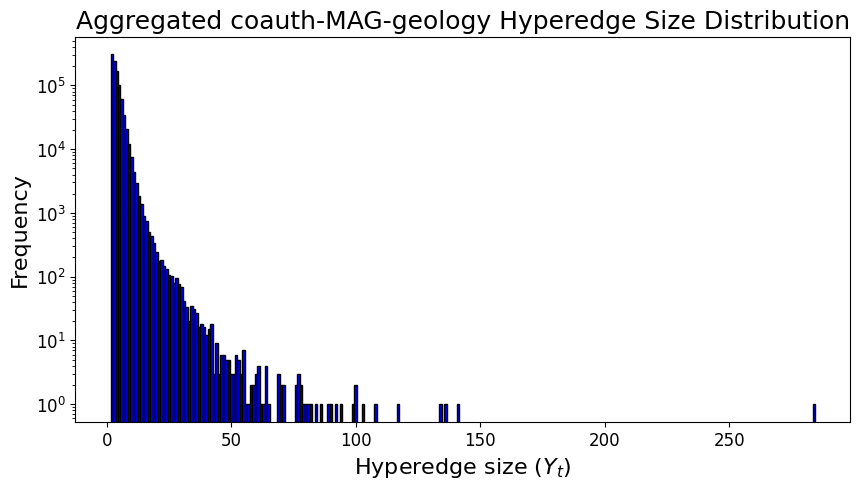

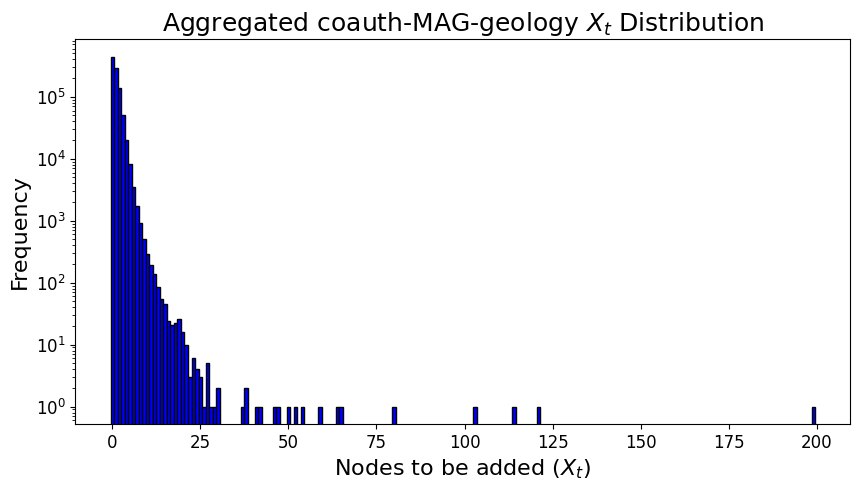

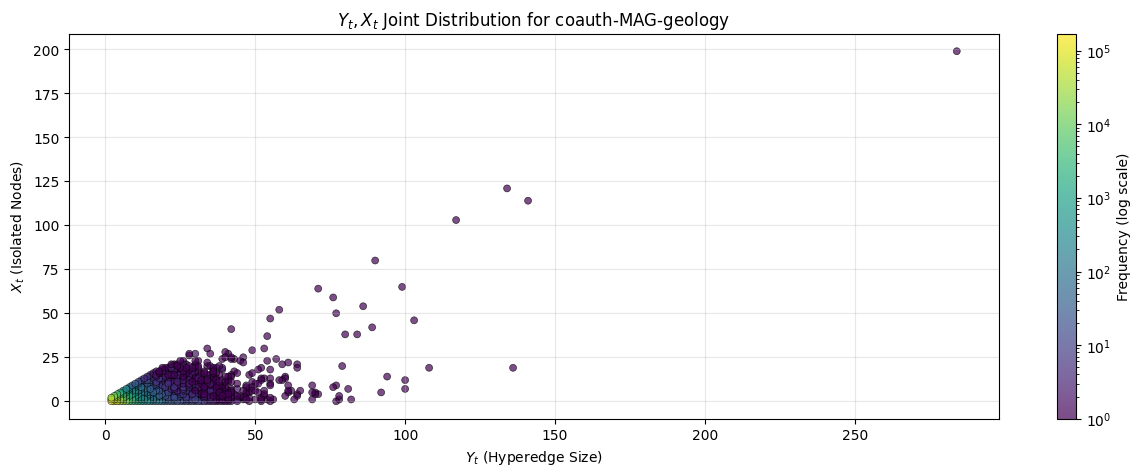

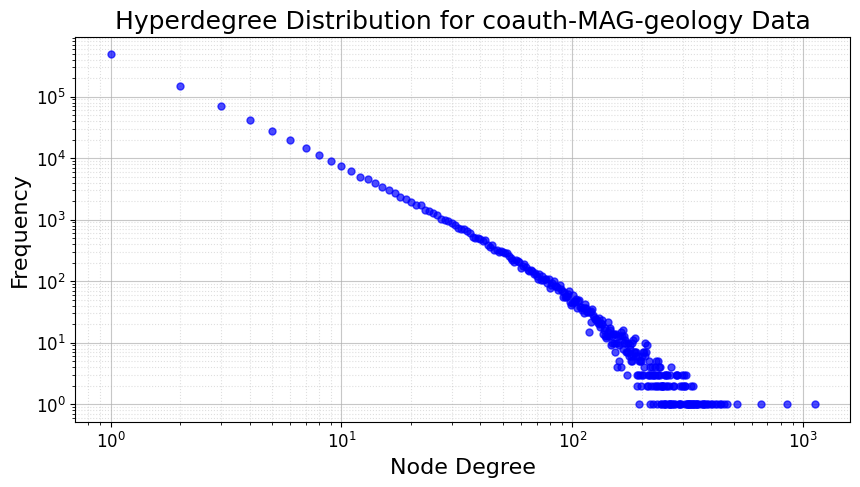

Number of nodes: 903973
Average node degree: 4.075009983705265
Number of edges: 965036
Average edge size: 3.8171622613042415


In [ ]:
name = "coauth-MAG-geology"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
coauth_geology_SF, coauth_geology_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("coauth-MAG-geology Simplicial Fraction: "+str(coauth_geology_SF))

100%|██████████| 834152/834152 [00:06<00:00, 121753.07it/s]


coauth-MAG-geology Simplicial Fraction: 0.0007278431581081396


Removing singletons
The hypergraph has 242048 nodes and 176730 timestamped hyperedges
The hypergraph has 140145 unique hyperedges
Number of components: 1
Size of largest component: 242048


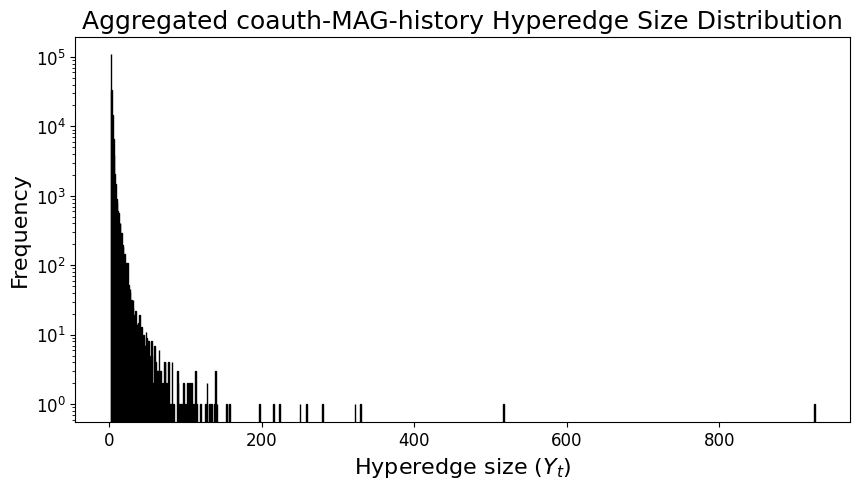

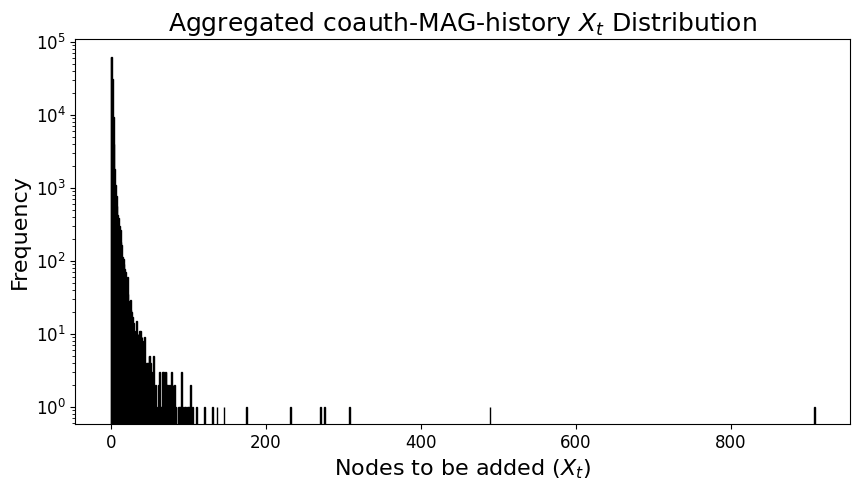

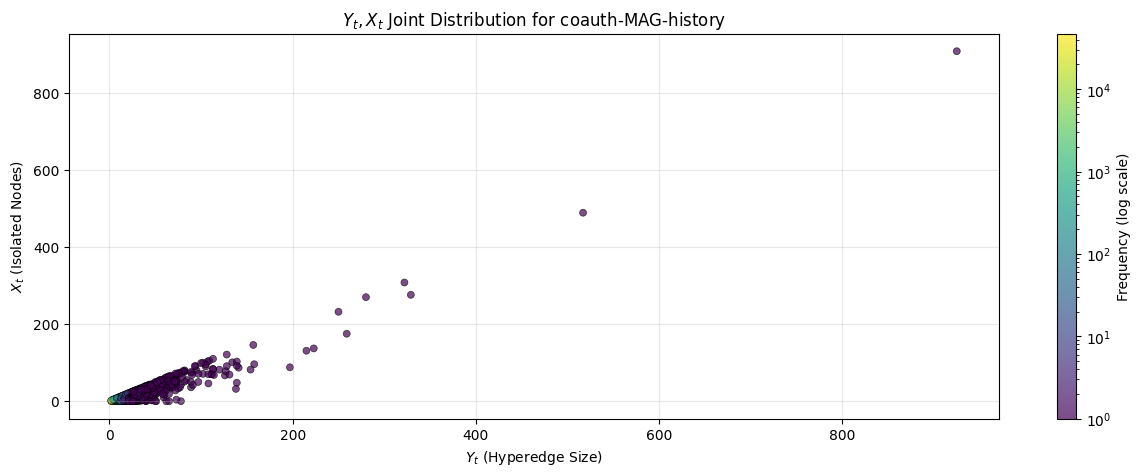

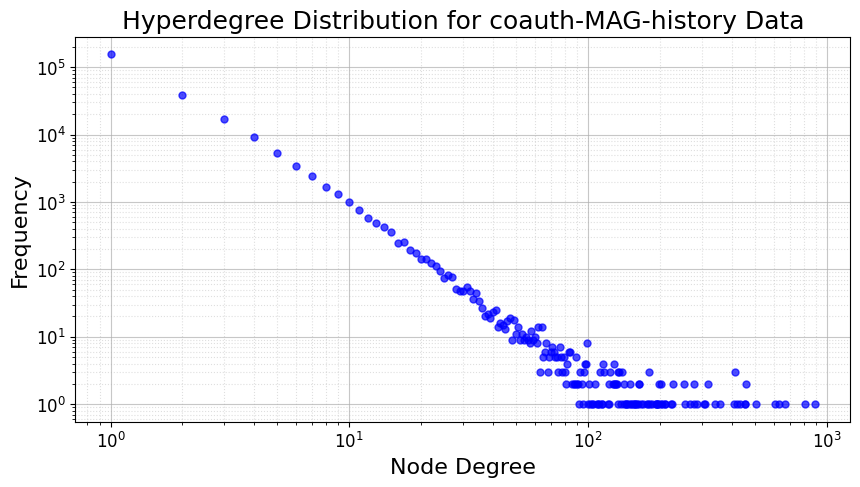

Number of nodes: 242048
Average node degree: 2.3064970584346907
Number of edges: 176730
Average edge size: 3.158959995473321


In [ ]:
name = "coauth-MAG-history"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
coauth_history_SF, coauth_history_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("coauth-MAG-history Simplicial Fraction: "+str(coauth_history_SF))

100%|██████████| 140145/140145 [00:00<00:00, 1570850.63it/s]

coauth-MAG-history Simplicial Fraction: 0.00027221069107489197


Removing singletons
The hypergraph has 1718 nodes and 127127 timestamped hyperedges
The hypergraph has 104039 unique hyperedges
Number of components: 1
Size of largest component: 1718


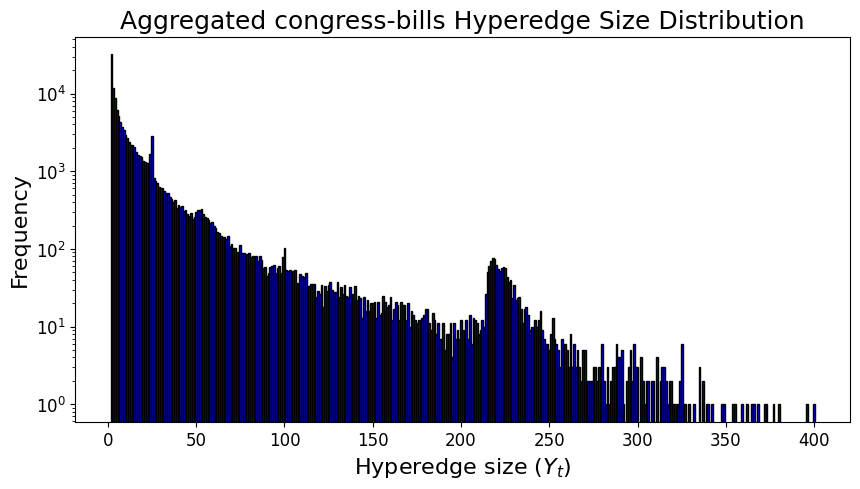

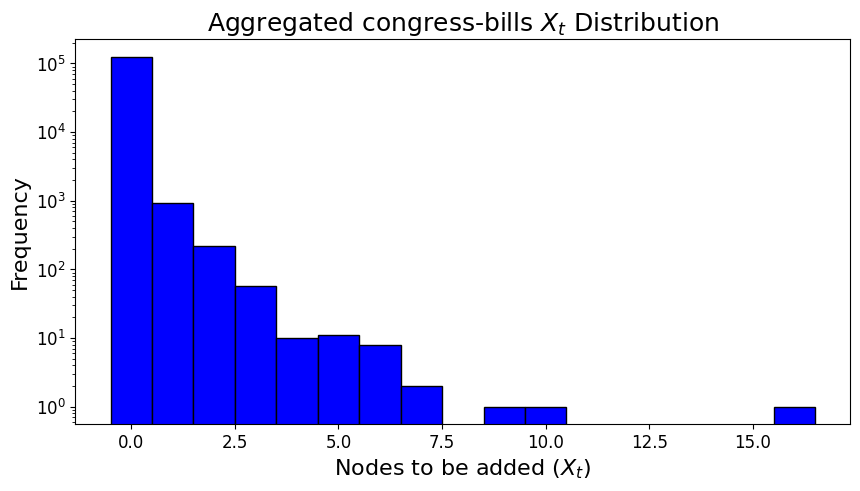

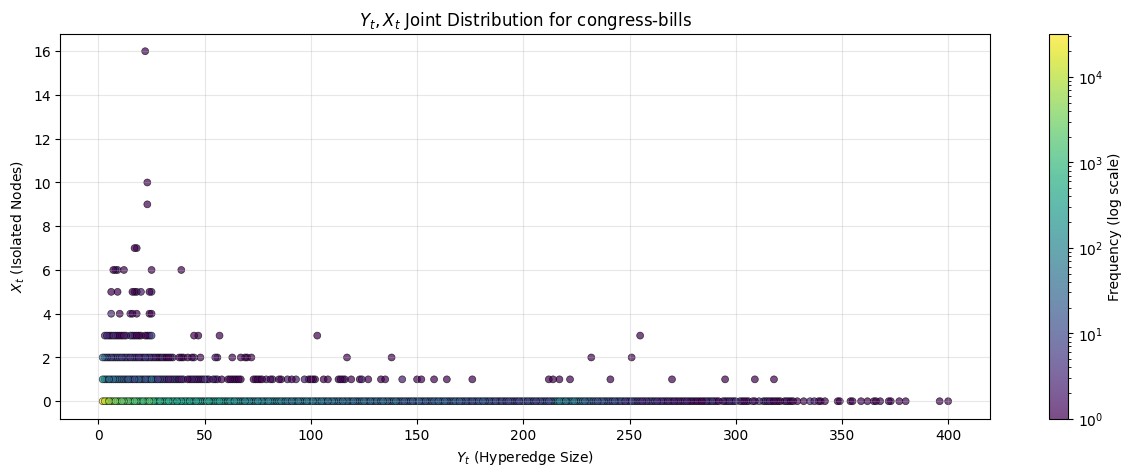

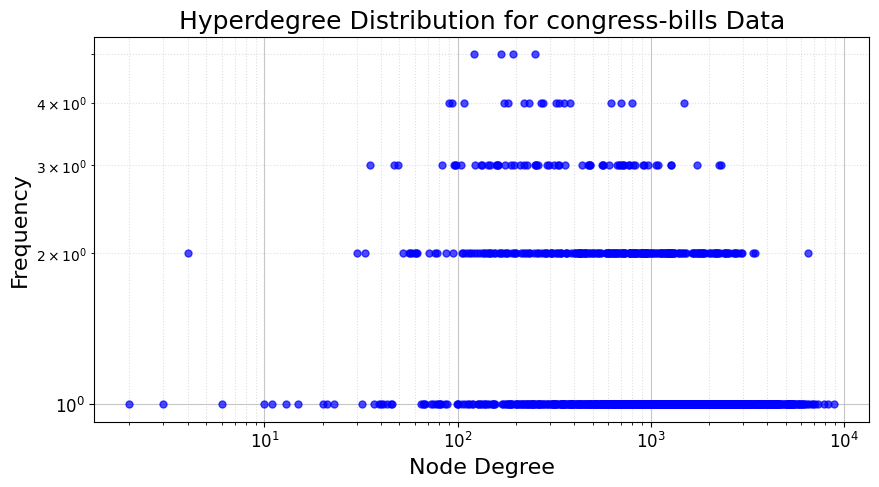

Number of nodes: 1718
Average node degree: 1331.127473806752
Number of edges: 127127
Average edge size: 17.98891659521581


In [ ]:
name = "congress-bills"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

---
## Communication Data:
* email-Enron
* email-EU

Removing singletons
The hypergraph has 143 nodes and 10454 timestamped hyperedges
Number of isolated nodes:  0
The hypergraph has 1459 unique hyperedges
Number of components: 1
Size of largest component: 143


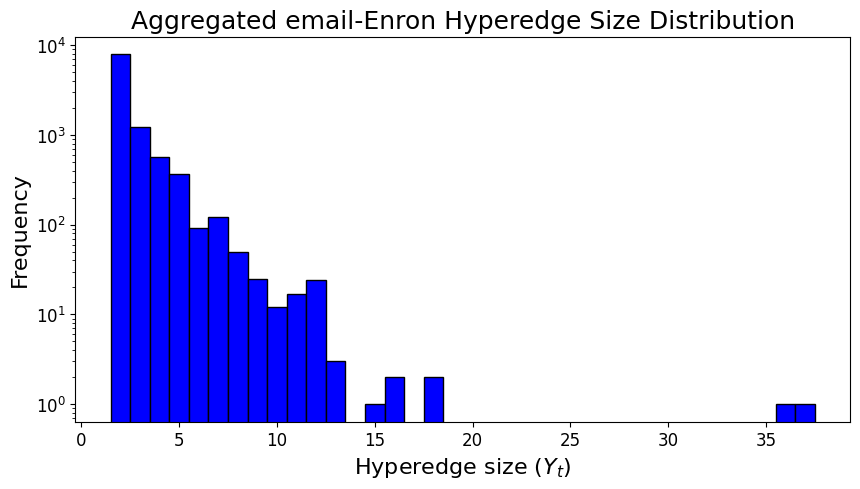

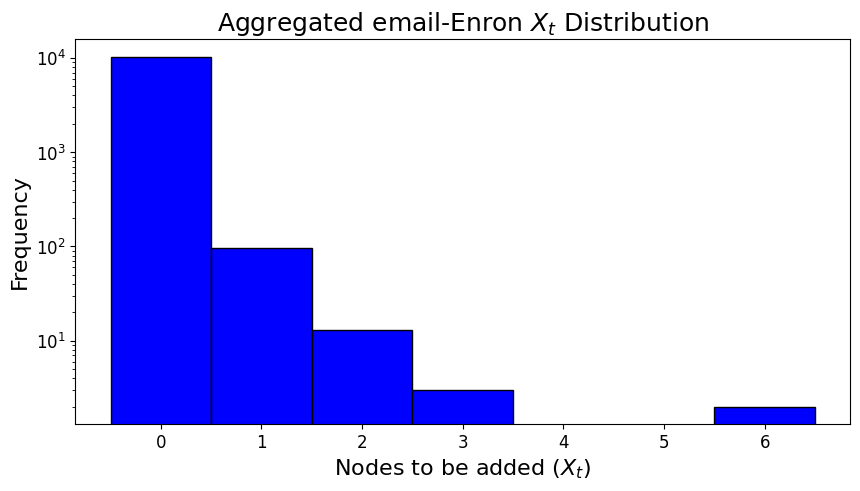

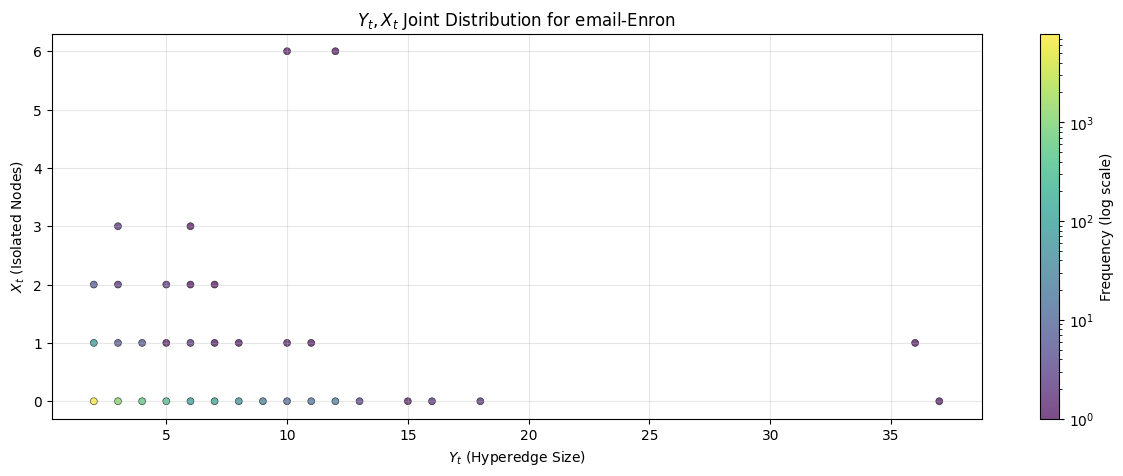

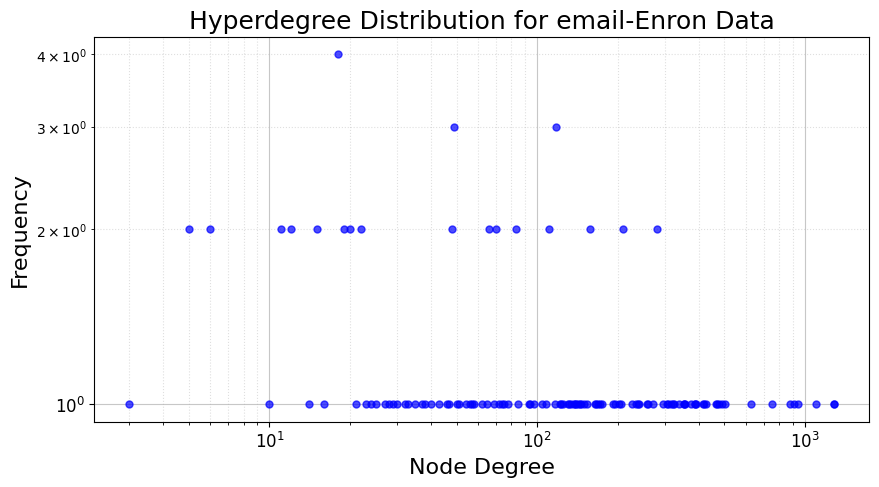

Number of nodes: 143
Average node degree: 185.1958041958042
Number of edges: 10454
Average edge size: 2.53328869332313


In [ ]:
clname = "email-Enron"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
isolated_nodes = H.nodes.isolates()
print("Number of isolated nodes: ", len(isolated_nodes))
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
enron_SF, enron_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("email-Enron Simplicial Fraction: "+str(enron_SF))

100%|██████████| 1459/1459 [00:00<00:00, 1716546.85it/s]

email-Enron Simplicial Fraction: 0.3046153846153846


Removing singletons
The hypergraph has 986 nodes and 209508 timestamped hyperedges
The hypergraph has 24520 unique hyperedges
Number of components: 1
Size of largest component: 986


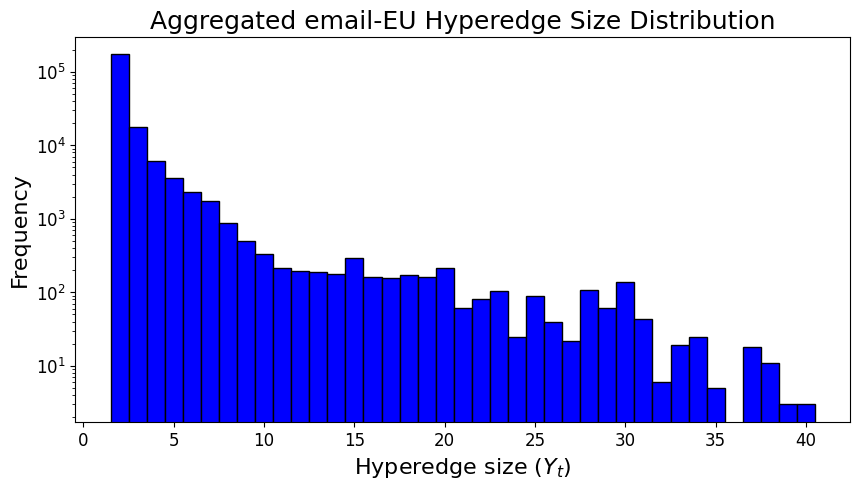

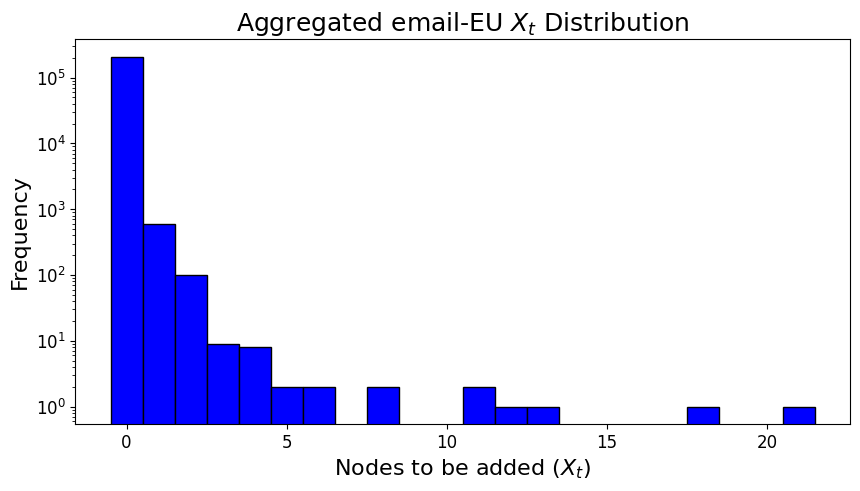

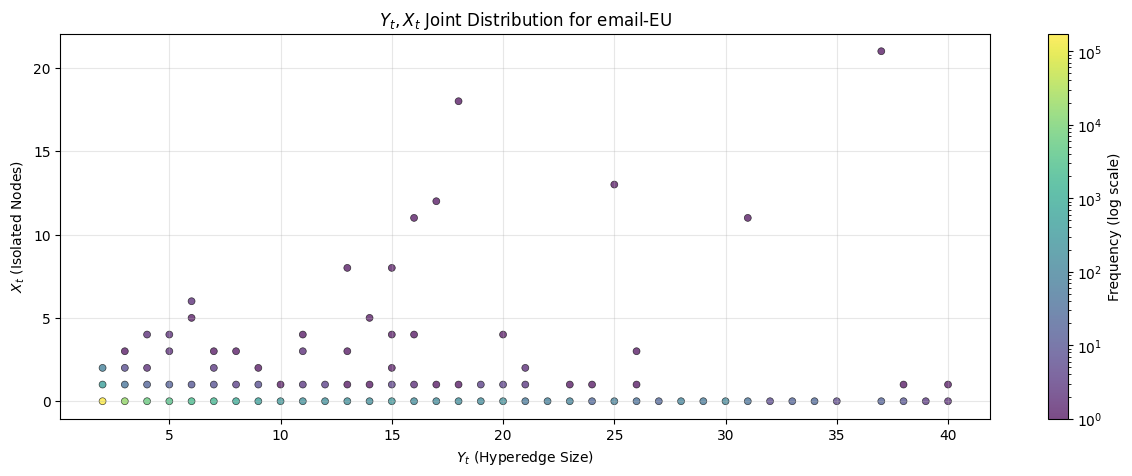

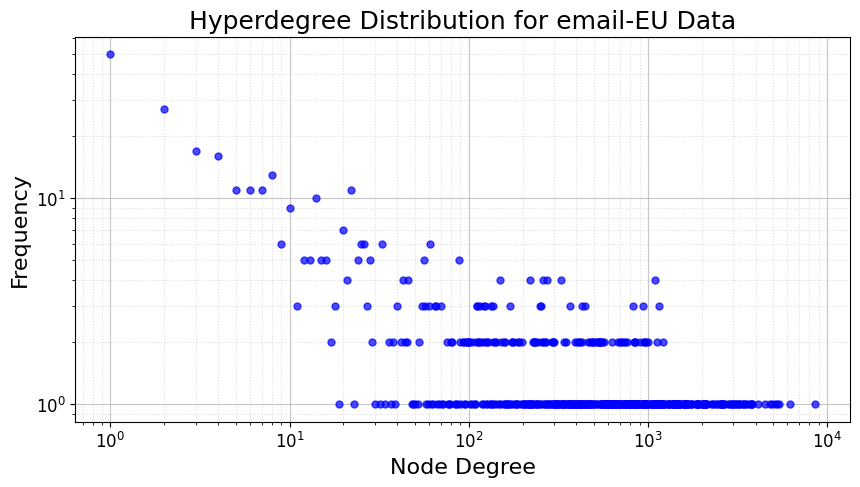

Number of nodes: 986
Average node degree: 544.4665314401623
Number of edges: 209508
Average edge size: 2.562403344979667


In [ ]:
name = "email-EU"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
EU_SF, EU_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("email-EU Simplicial Fraction: "+str(EU_SF))

100%|██████████| 24520/24520 [00:00<00:00, 1190093.78it/s]

email-EU Simplicial Fraction: 0.2957423302456021


Removing singletons
The hypergraph has 82075 nodes and 113575 timestamped hyperedges
The hypergraph has 111802 unique hyperedges
Number of components: 1
Size of largest component: 82075


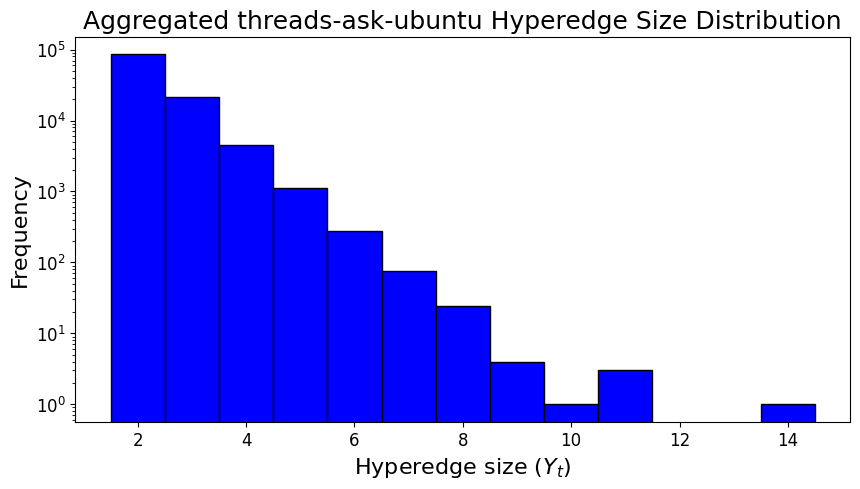

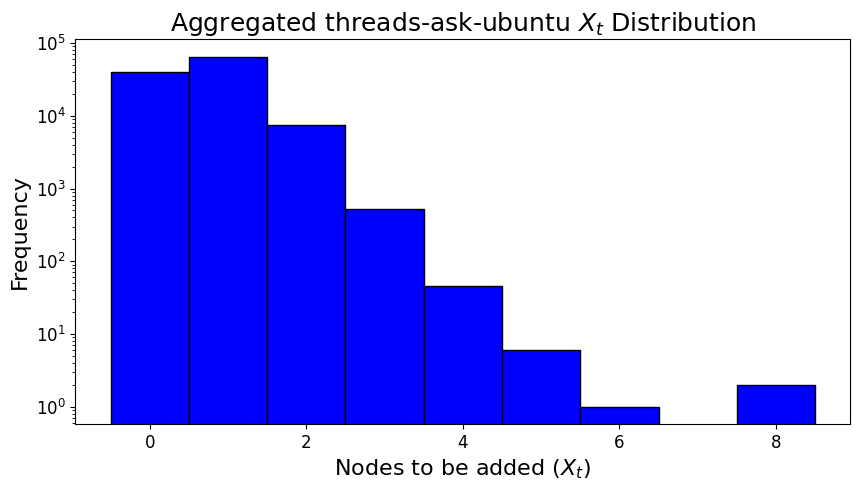

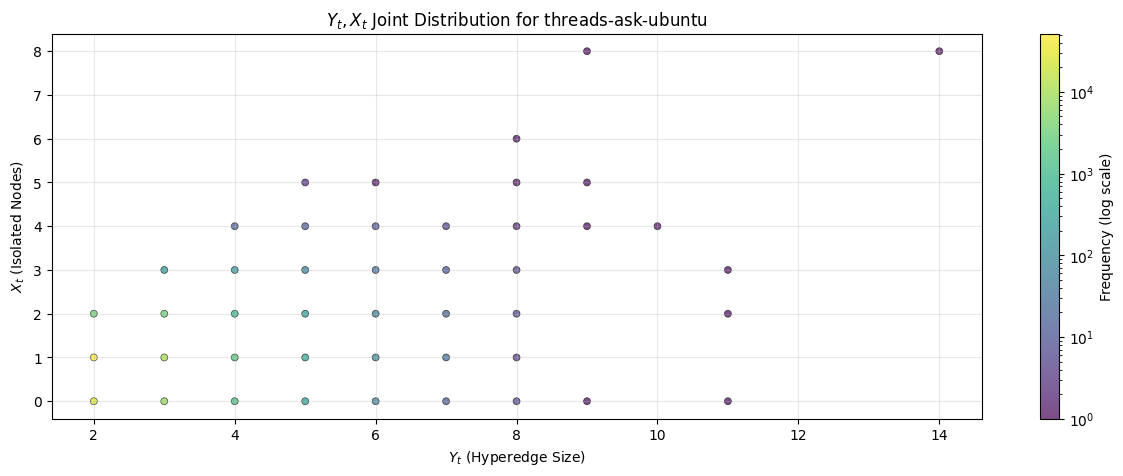

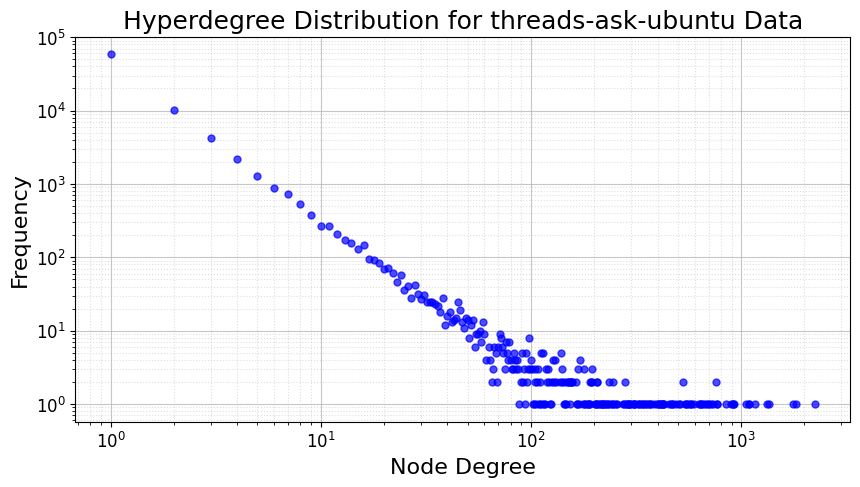

Number of nodes: 82075
Average node degree: 3.202193116052391
Number of edges: 113575
Average edge size: 2.3140655954215275


In [ ]:
name = "threads-ask-ubuntu"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
threads_ubuntu_SF, threads_ubuntu_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("threads-ask-ubuntu Simplicial Fraction: "+str(threads_ubuntu_SF))

100%|██████████| 111802/111802 [00:00<00:00, 2087405.97it/s]

threads-ask-ubuntu Simplicial Fraction: 0.0009803565593115718


Removing singletons
The hypergraph has 152702 nodes and 563155 timestamped hyperedges
The hypergraph has 534768 unique hyperedges
Number of components: 1
Size of largest component: 152702


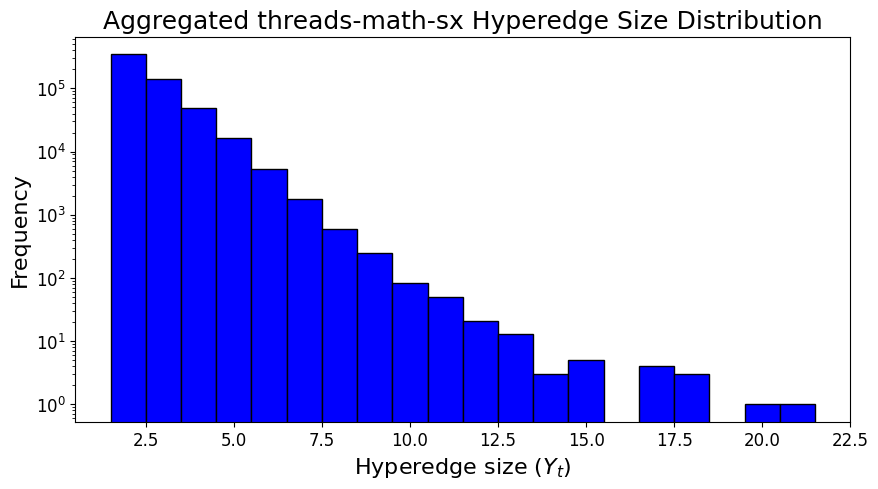

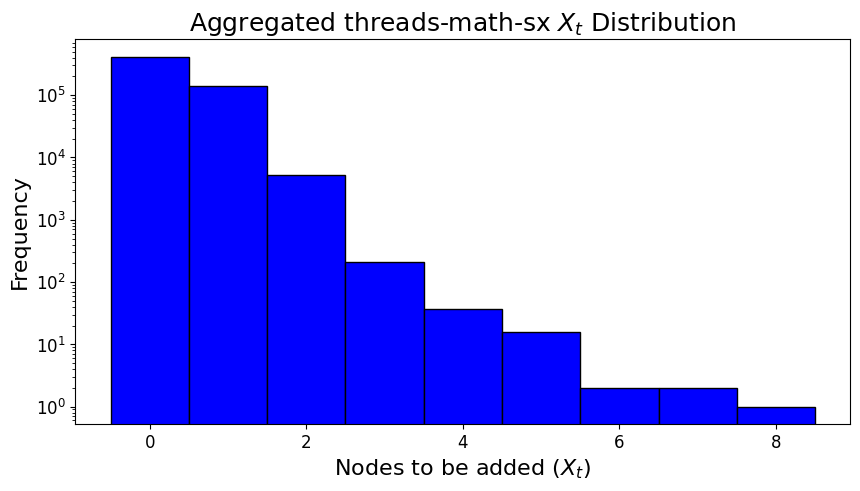

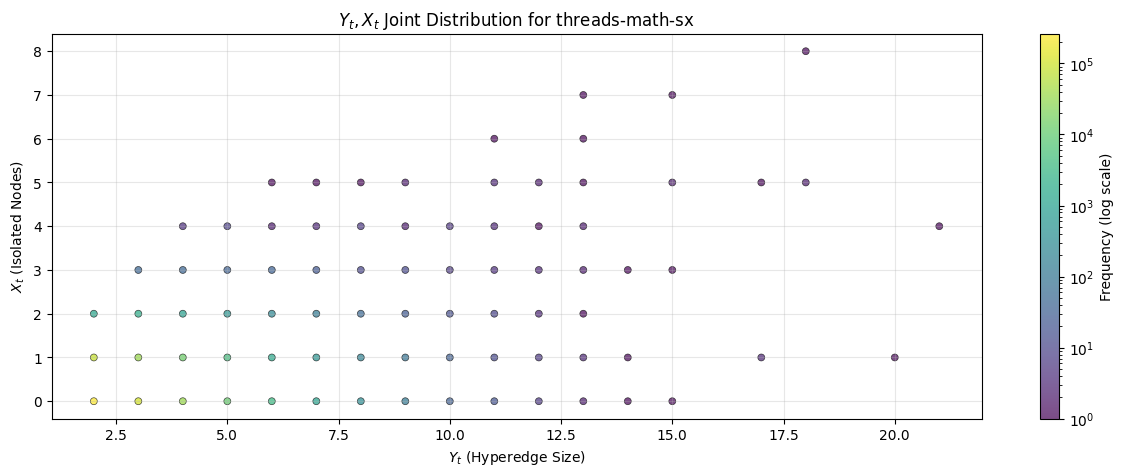

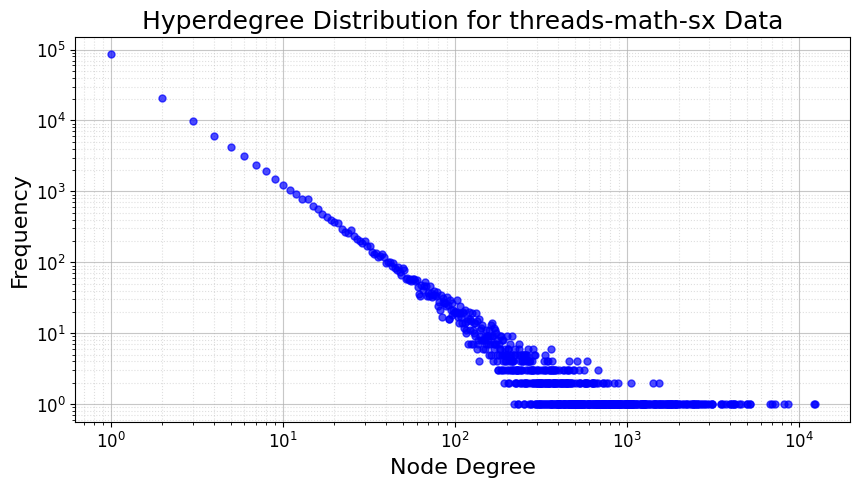

Number of nodes: 152702
Average node degree: 9.516528925619834
Number of edges: 563155
Average edge size: 2.5804494322167075


In [ ]:
name = "threads-math-sx"
H = xgi.load_xgi_data(name)
print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
threads_math_SF, threads_math_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("threads-math-sx Simplicial Fraction: "+str(threads_math_SF))

100%|██████████| 534768/534768 [00:01<00:00, 323116.89it/s] 


threads-math-sx Simplicial Fraction: 0.004274158032589296


---
## Proximity Data:
* `contact-high-school`
*

Removing singletons
The hypergraph has 327 nodes and 172035 timestamped hyperedges
The hypergraph has 7818 unique hyperedges
Number of components: 1
Size of largest component: 327


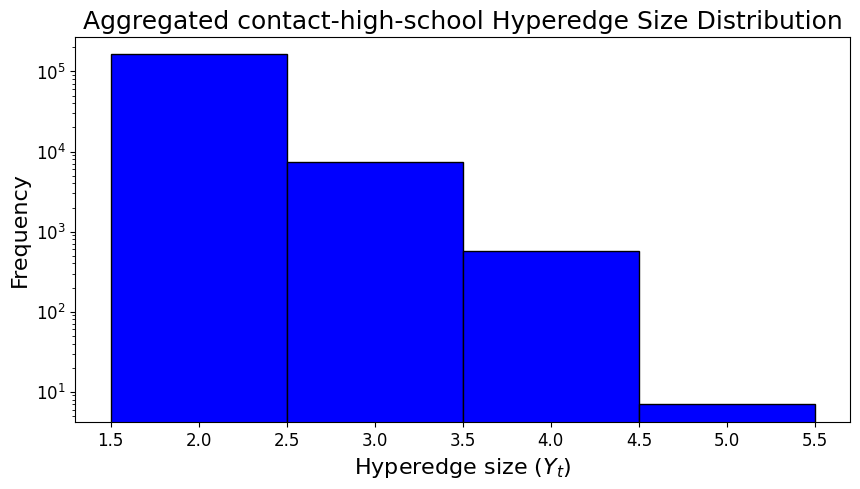

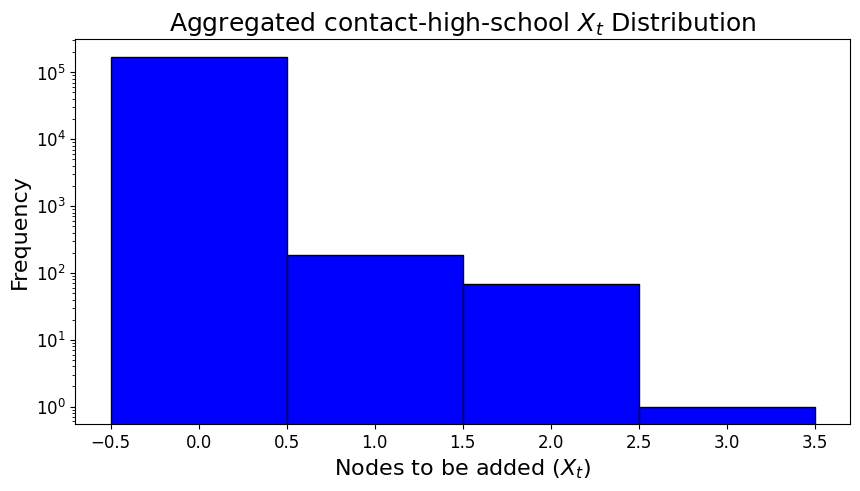

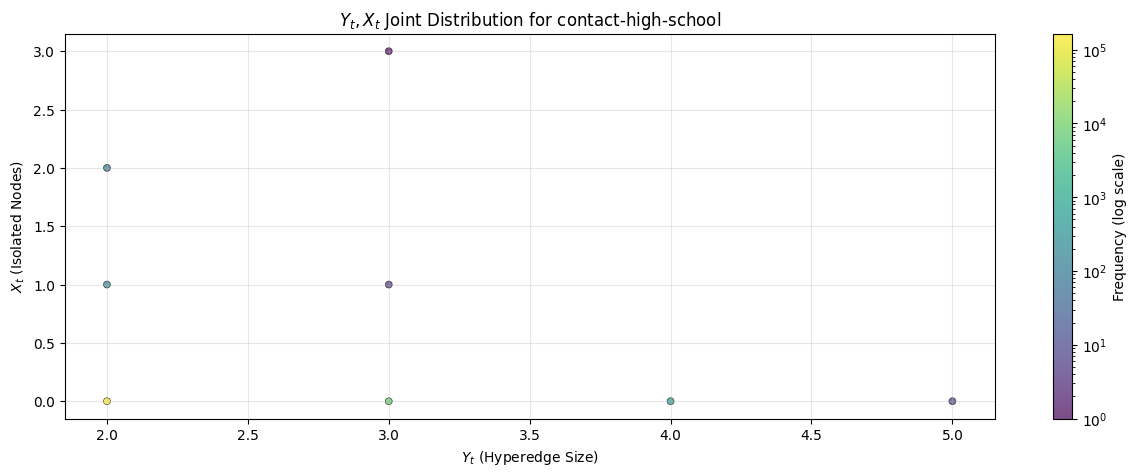

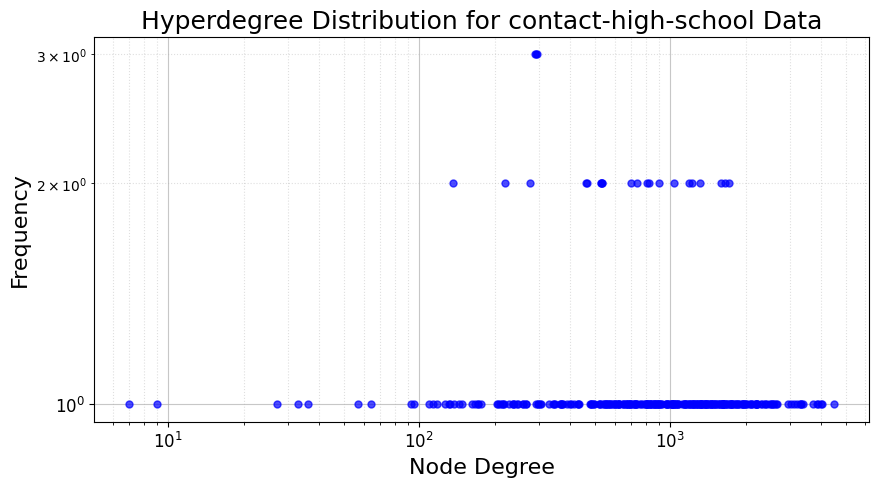

Number of nodes: 327
Average node degree: 1078.6483180428133
Number of edges: 172035
Average edge size: 2.0502688406428926


In [ ]:
name = "contact-high-school"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
contact_HS_SF, contact_HS_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("contact-high-school Simplicial Fraction: "+str(contact_HS_SF))

100%|██████████| 7818/7818 [00:00<00:00, 1856798.91it/s]

contact-high-school Simplicial Fraction: 0.8064655172413793


Removing singletons
The hypergraph has 242 nodes and 106879 timestamped hyperedges
The hypergraph has 12704 unique hyperedges
Number of components: 1
Size of largest component: 242


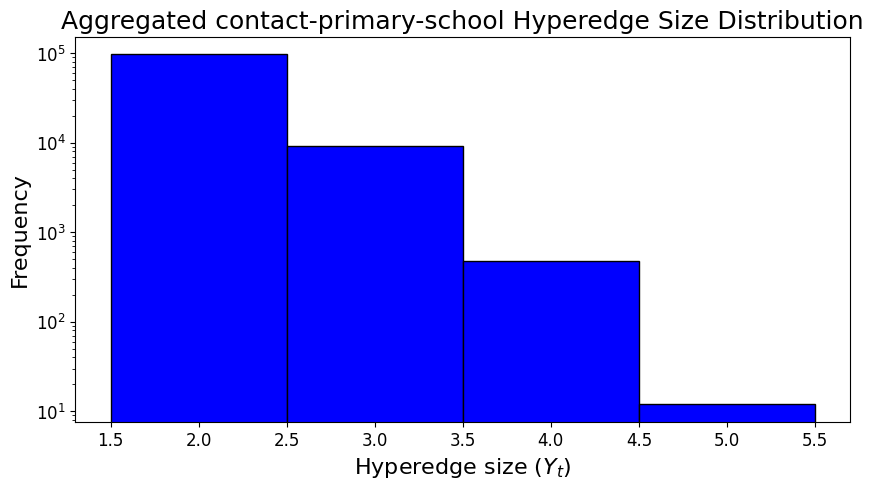

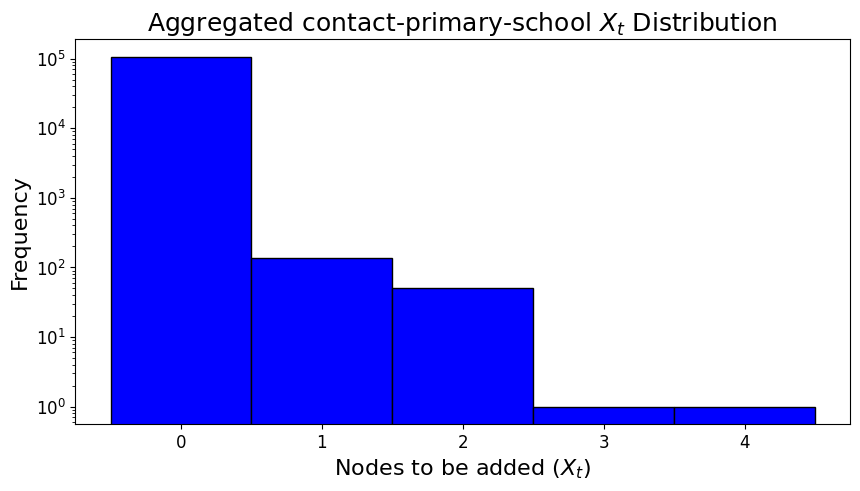

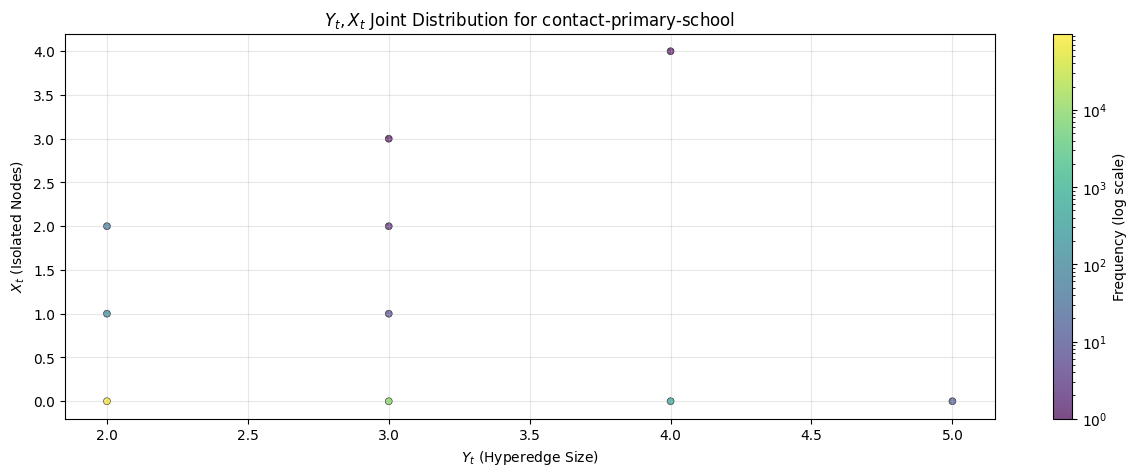

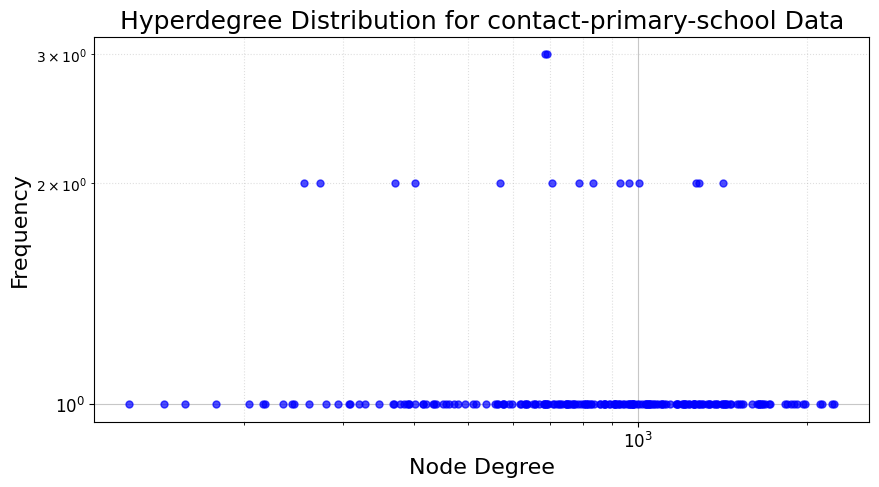

Number of nodes: 242
Average node degree: 925.6115702479339
Number of edges: 106879
Average edge size: 2.0958092796526913


In [ ]:
name = "contact-primary-school"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
contact_PS_SF, contact_PS_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("contact-primary-school Simplicial Fraction: "+str(contact_PS_SF))

100%|██████████| 12704/12704 [00:00<00:00, 1487062.91it/s]

contact-primary-school Simplicial Fraction: 0.8470540758676351


Removing singletons
The hypergraph has 75 nodes and 27834 timestamped hyperedges
The hypergraph has 1824 unique hyperedges
Number of components: 1
Size of largest component: 75


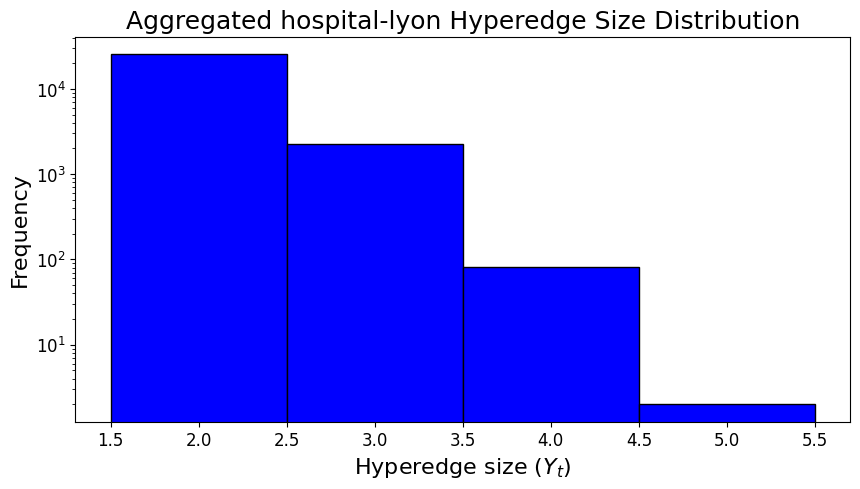

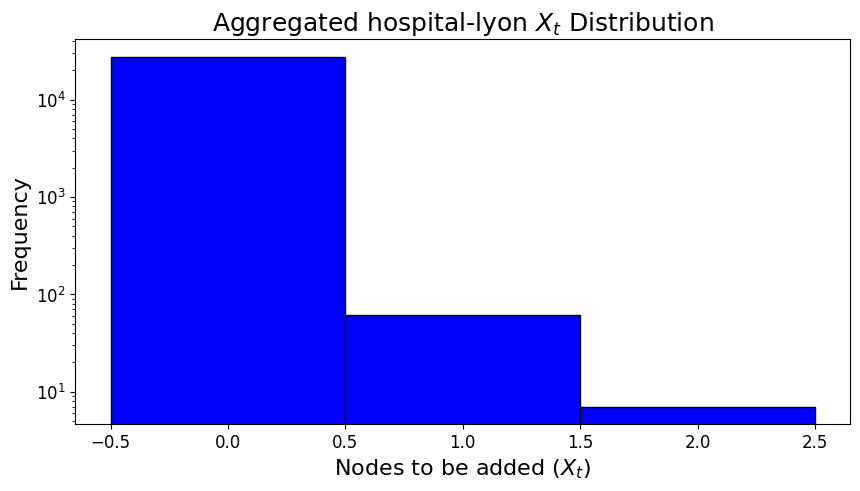

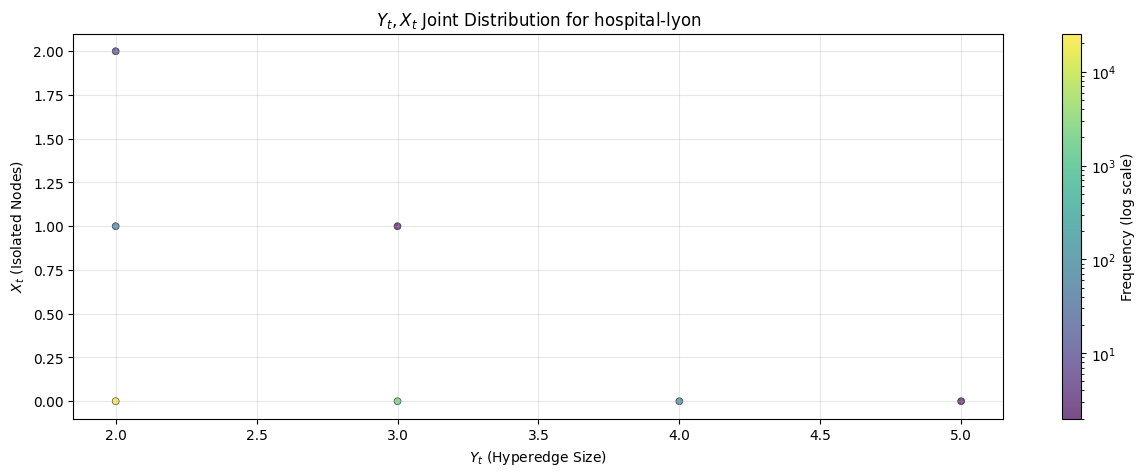

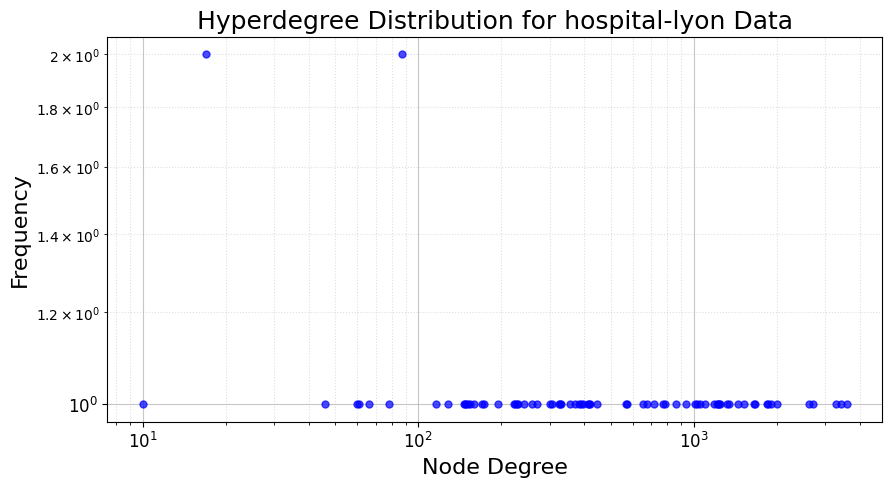

Number of nodes: 75
Average node degree: 774.68
Number of edges: 27834
Average edge size: 2.0874110799741326


In [ ]:
name = "hospital-lyon"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
hospital_SF, hospital_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("hospital-lyon Simplicial Fraction: "+str(hospital_SF))

100%|██████████| 1824/1824 [00:00<00:00, 1088097.07it/s]

hospital-lyon Simplicial Fraction: 0.9121338912133892


Removing singletons
The hypergraph has 84 nodes and 99910 timestamped hyperedges
The hypergraph has 431 unique hyperedges
Number of components: 1
Size of largest component: 84


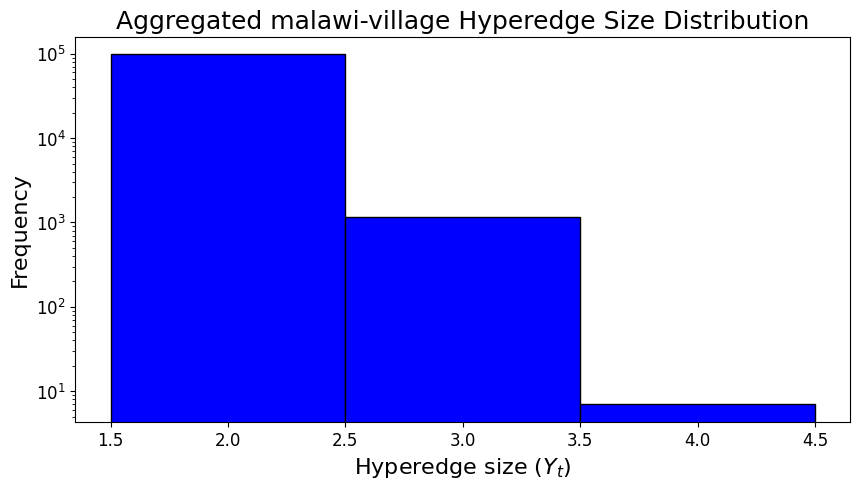

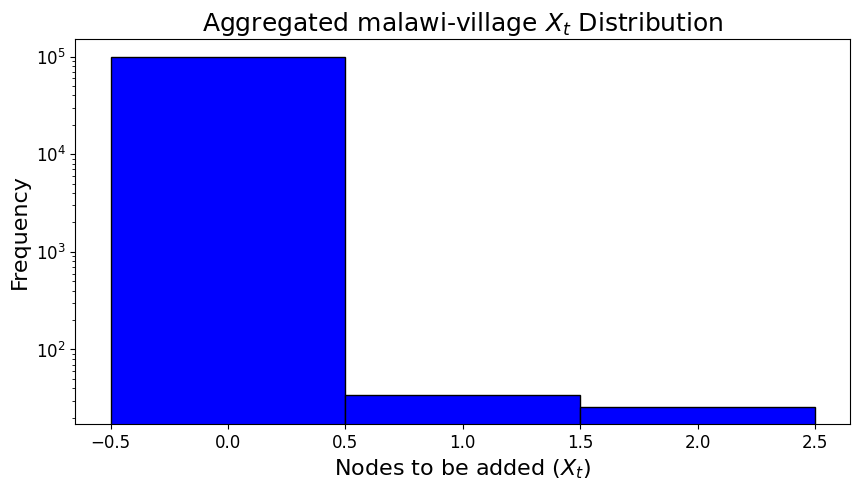

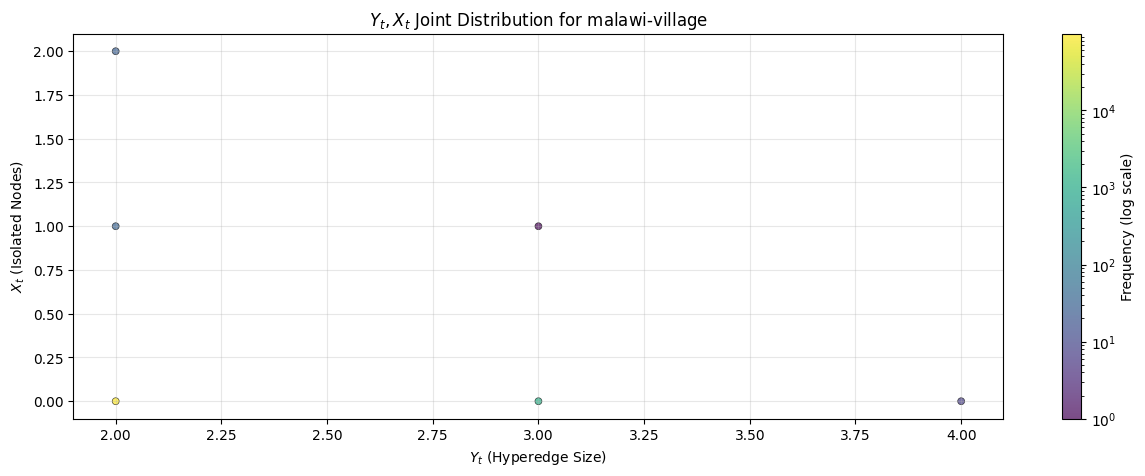

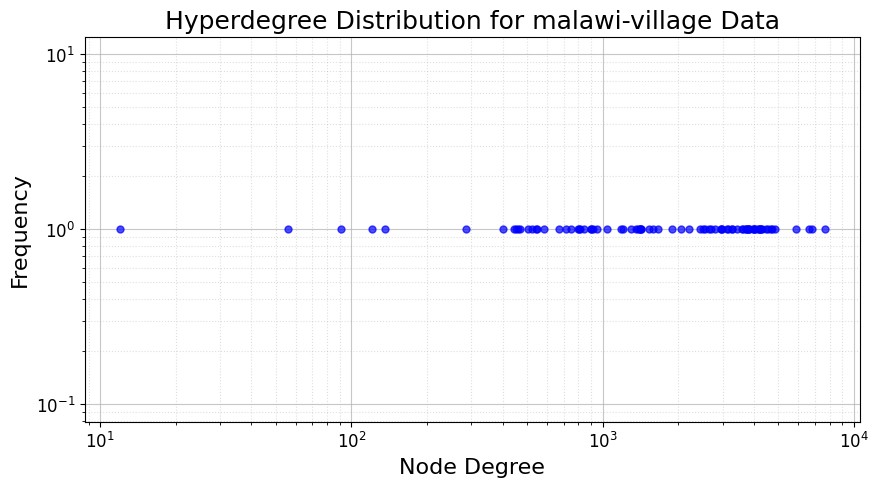

Number of nodes: 86
Average node degree: 2392.9166666666665
Number of edges: 99942
Average edge size: 2.0118568769886536


In [ ]:
name = "malawi-village"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
malawi_SF, malawi_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("malawi-village Simplicial Fraction: "+str(malawi_SF))

100%|██████████| 431/431 [00:00<00:00, 1012175.27it/s]

malawi-village Simplicial Fraction: 0.9555555555555556


Removing singletons
The hypergraph has 410 nodes and 14274 timestamped hyperedges
The hypergraph has 3350 unique hyperedges
Number of components: 1
Size of largest component: 410


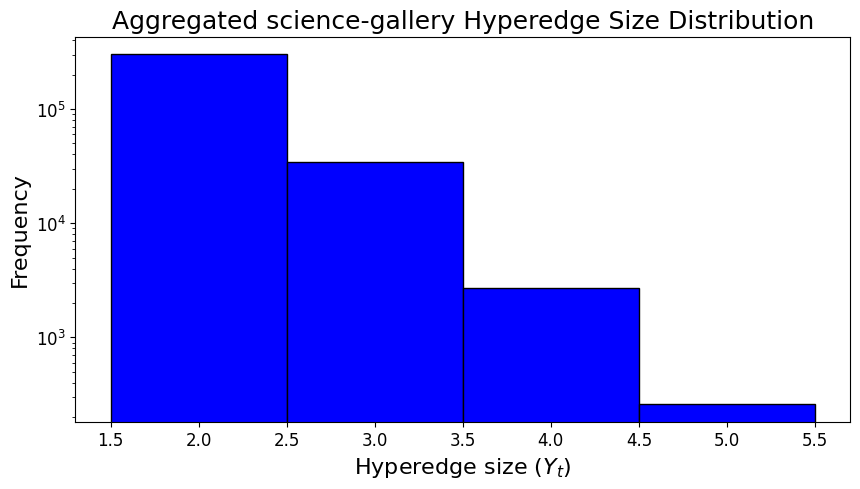

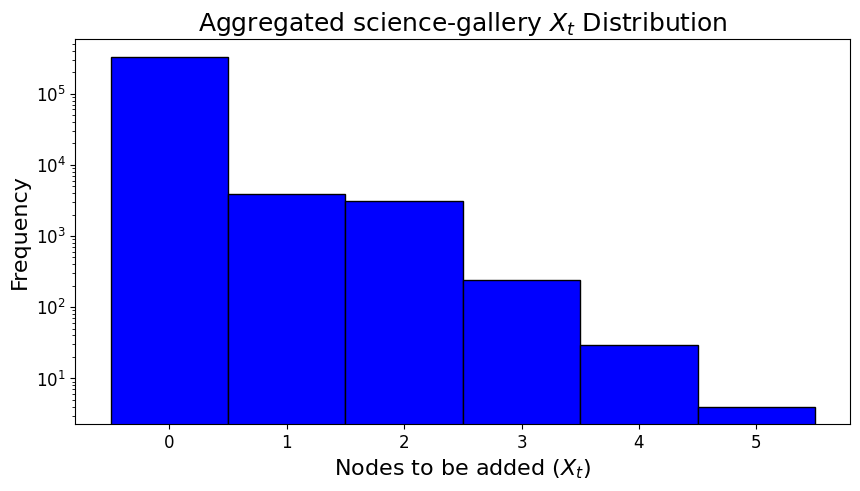

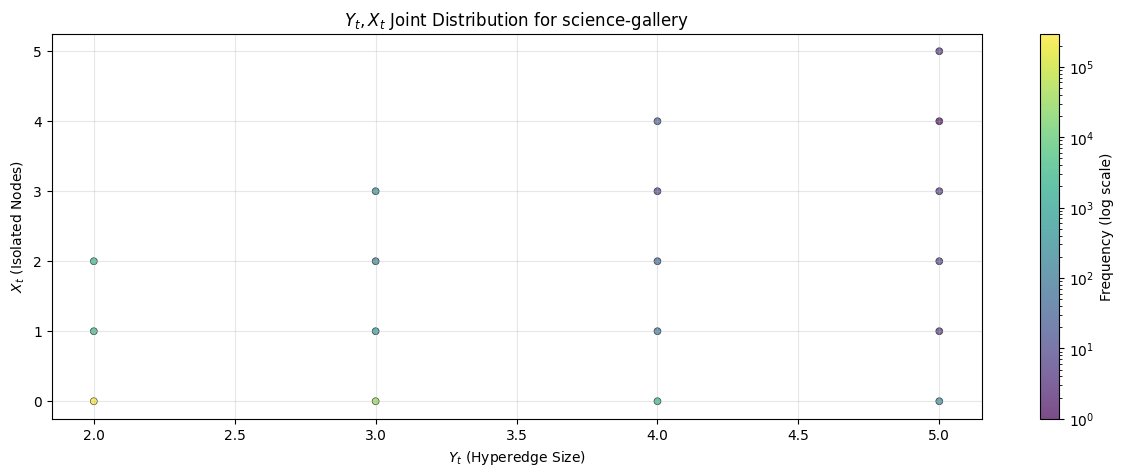

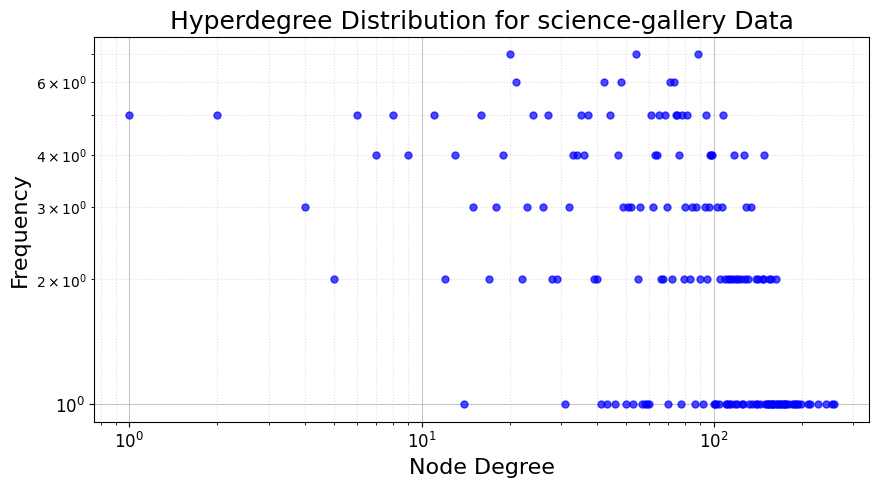

Number of nodes: 10972
Average node degree: 73.52195121951219
Number of edges: 338765
Average edge size: 2.1185482561657785


In [ ]:
name = "science-gallery"
H = xgi.load_xgi_data(name)


print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
science_gallery_SF, science_gallery_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("science-gallery Simplicial Fraction: "+str(science_gallery_SF))

100%|██████████| 3350/3350 [00:00<00:00, 1578754.88it/s]

science-gallery Simplicial Fraction: 0.7229336437718277


Removing singletons
The hypergraph has 403 nodes and 54305 timestamped hyperedges
The hypergraph has 10541 unique hyperedges
Number of components: 1
Size of largest component: 403


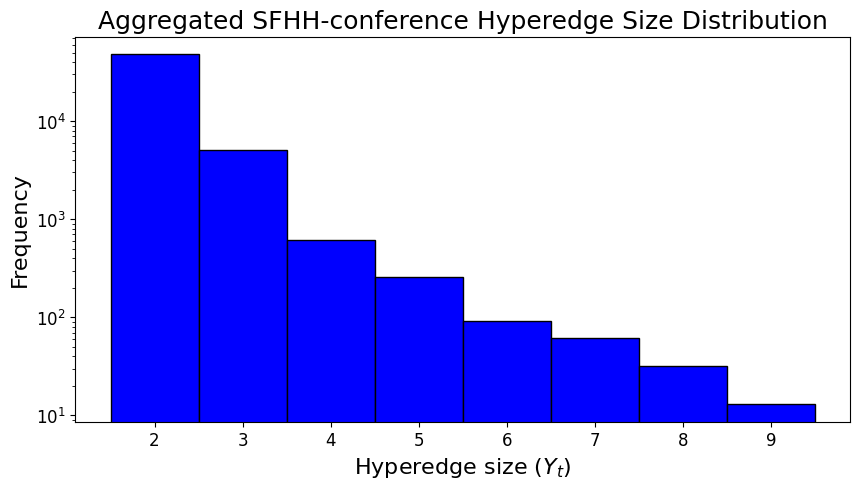

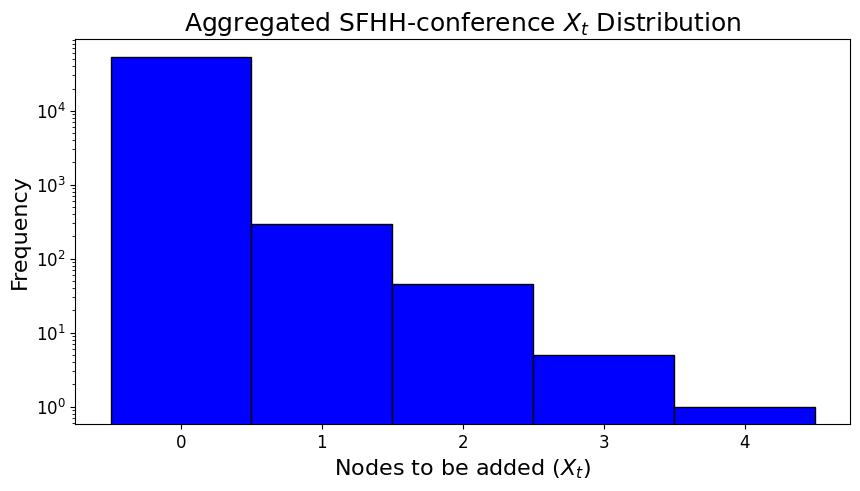

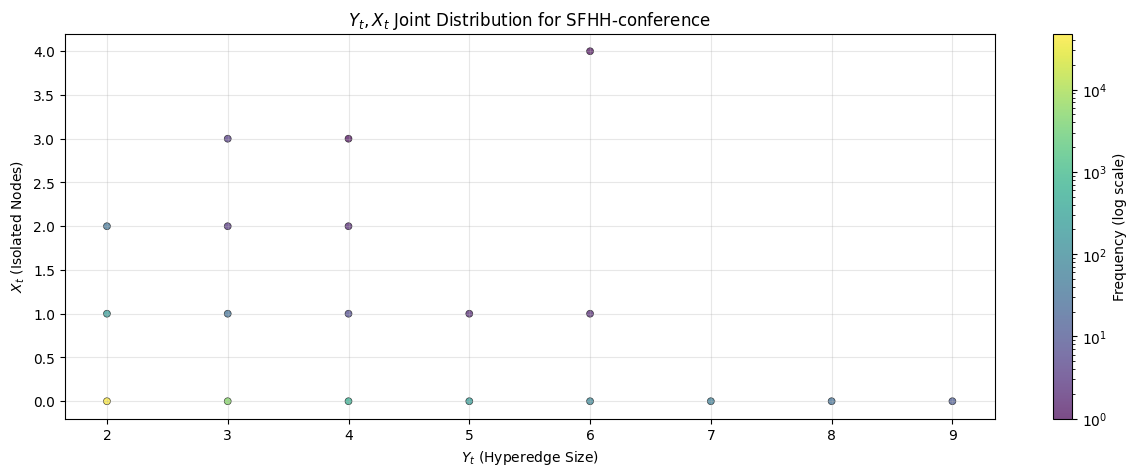

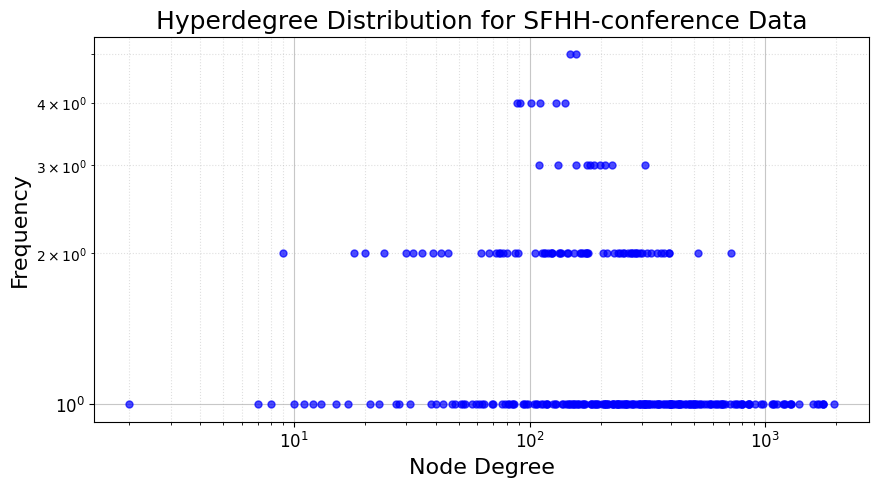

Number of nodes: 403
Average node degree: 289.4193548387097
Number of edges: 54305
Average edge size: 2.147794862351533


In [ ]:
name = "SFHH-conference"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
SFHH_SF, SFHH_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("SFHH-conference Simplicial Fraction: "+str(SFHH_SF))

100%|██████████| 10541/10541 [00:00<00:00, 2550456.21it/s]

SFHH-conference Simplicial Fraction: 0.41223053233611967


Removing singletons
The hypergraph has 113 nodes and 19036 timestamped hyperedges
The hypergraph has 2434 unique hyperedges
Number of components: 1
Size of largest component: 113


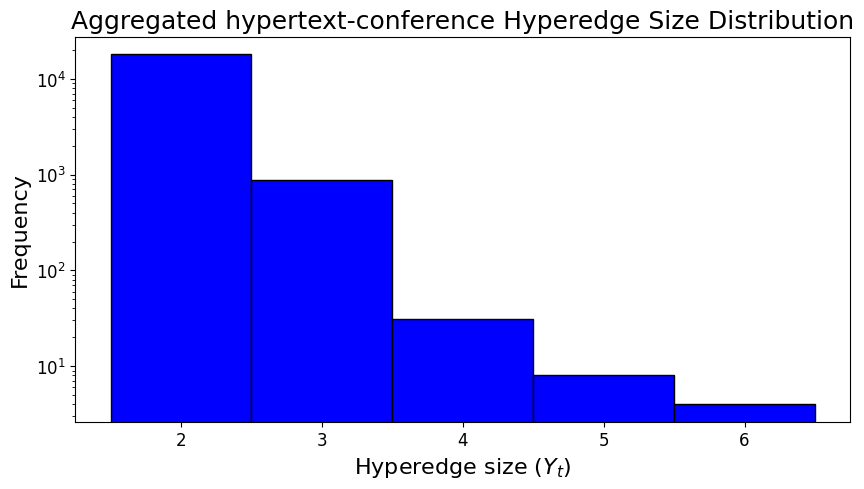

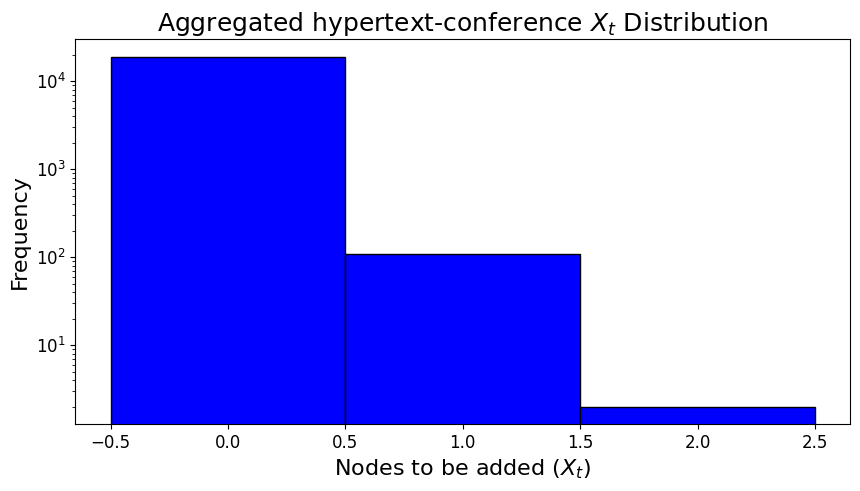

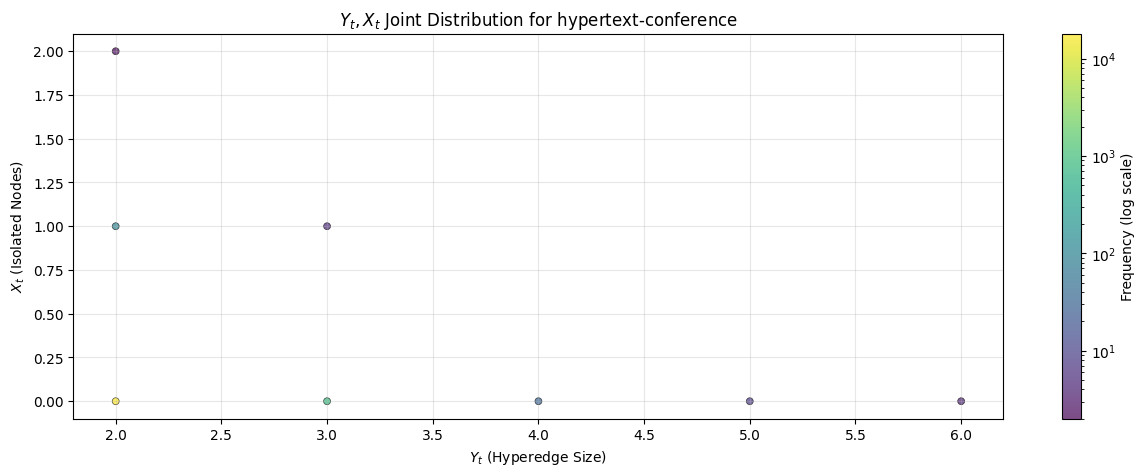

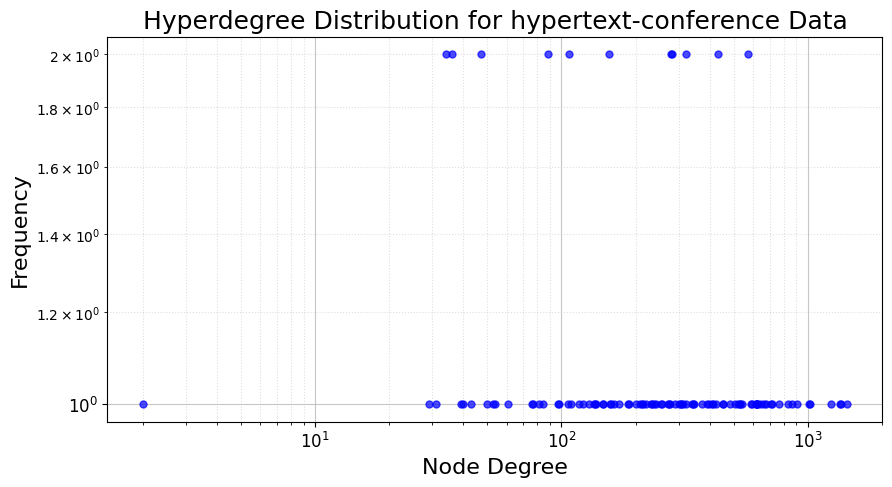

Number of nodes: 113
Average node degree: 345.5575221238938
Number of edges: 19036
Average edge size: 2.0512712754780416


In [ ]:
name = "hypertext-conference"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
hypertext_SF, hypertext_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("hypertext-conference Simplicial Fraction: "+str(hypertext_SF))

100%|██████████| 2434/2434 [00:00<00:00, 1383512.12it/s]

hypertext-conference Simplicial Fraction: 0.7099697885196374


Removing singletons
The hypergraph has 92 nodes and 9644 timestamped hyperedges
The hypergraph has 787 unique hyperedges
Number of components: 1
Size of largest component: 92


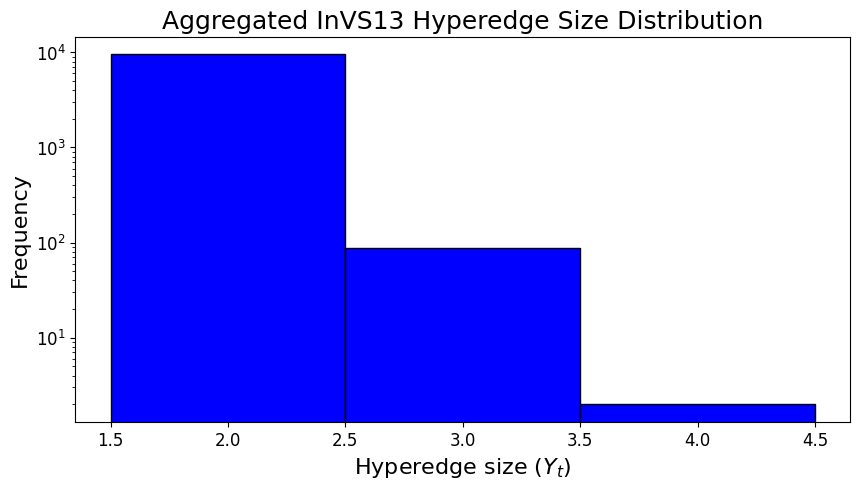

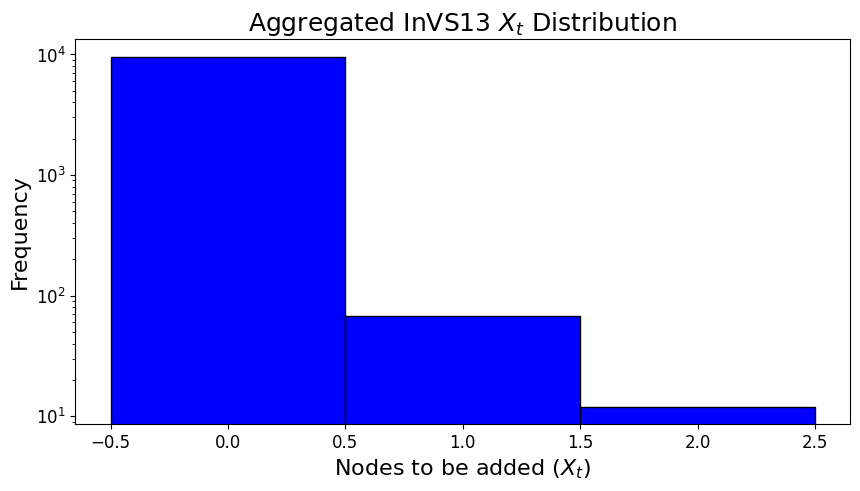

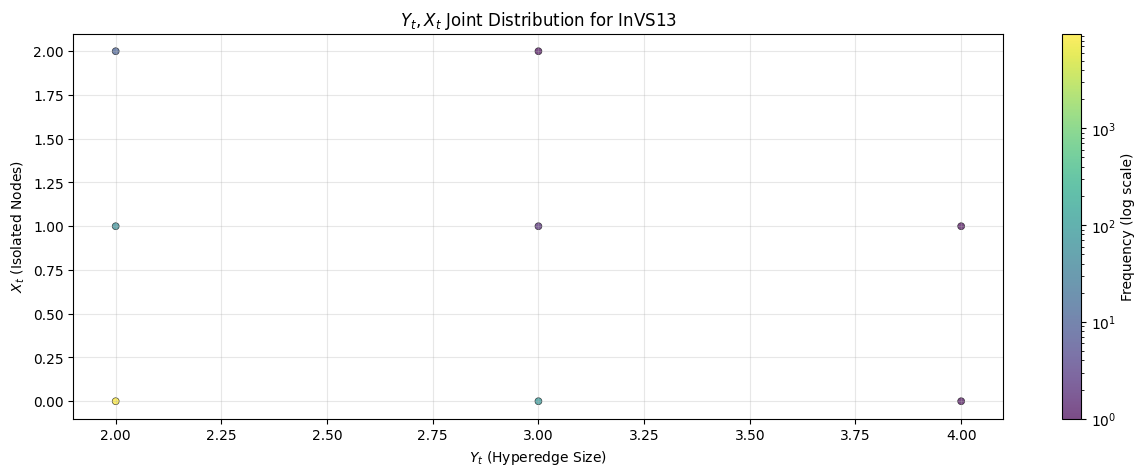

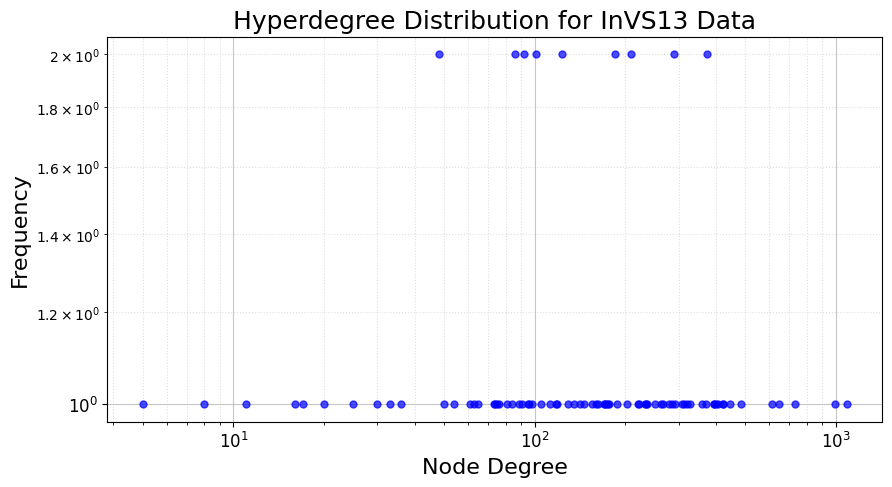

Number of nodes: 92
Average node degree: 210.65217391304347
Number of edges: 9644
Average edge size: 2.009539610120282


In [ ]:
name = "InVS13"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
InVS13_SF, InVS13_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("InVS13 Simplicial Fraction: "+str(InVS13_SF))

100%|██████████| 787/787 [00:00<00:00, 2251648.87it/s]

InVS13 Simplicial Fraction: 0.7391304347826086


Removing singletons
The hypergraph has 217 nodes and 73822 timestamped hyperedges
The hypergraph has 4909 unique hyperedges
Number of components: 1
Size of largest component: 217


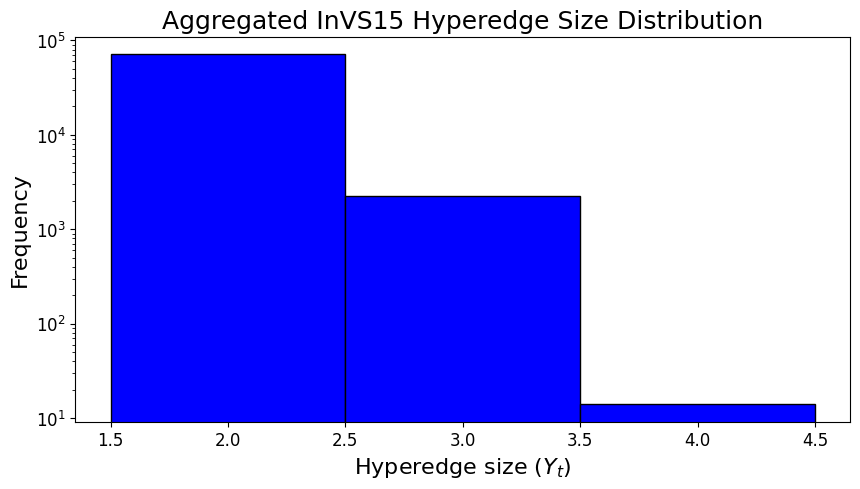

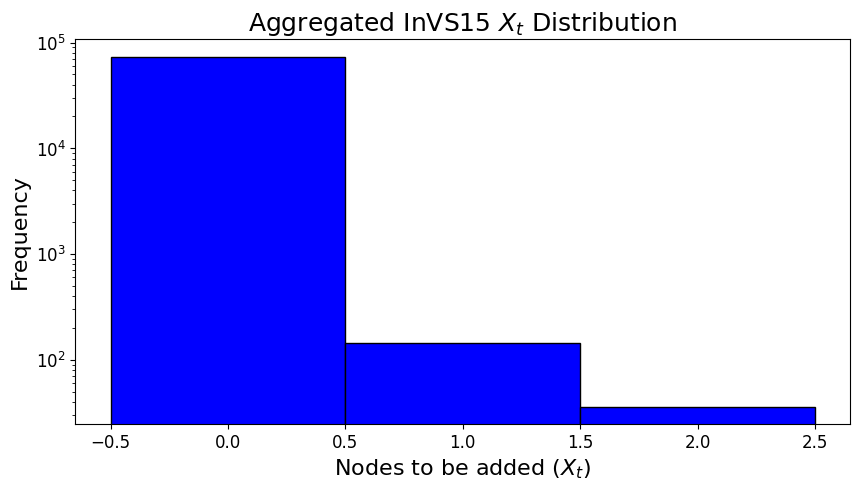

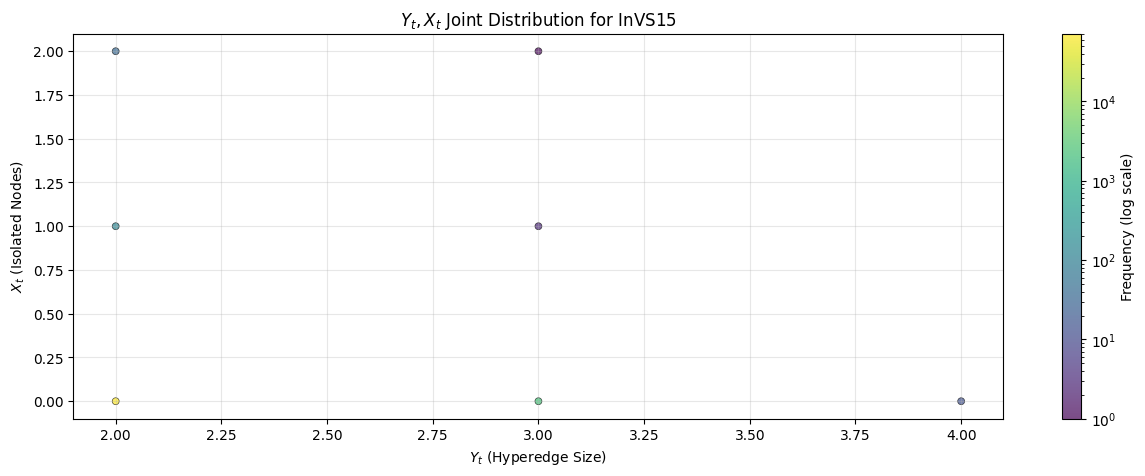

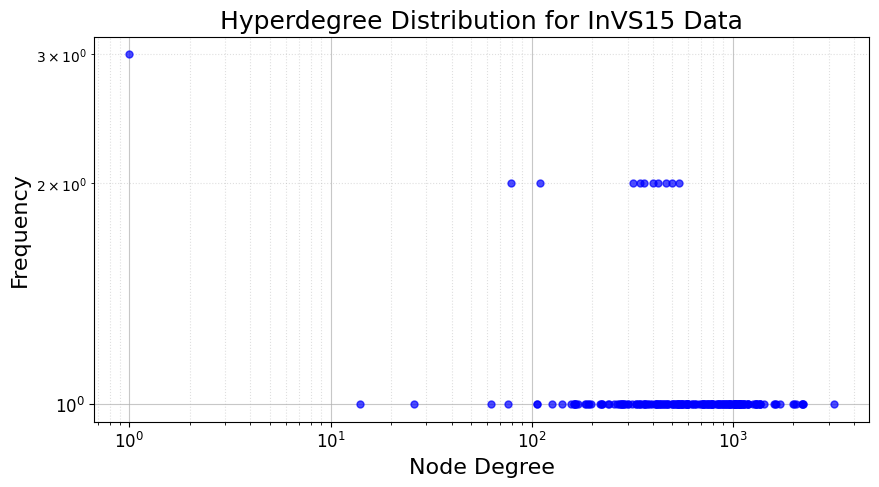

Number of nodes: 217
Average node degree: 691.0092165898618
Number of edges: 73822
Average edge size: 2.031223754436347


In [ ]:
name = "InVS15"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
InVS15_SF, InVS15_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("InVS15 Simplicial Fraction: "+str(InVS15_SF))

100%|██████████| 4909/4909 [00:00<00:00, 1596111.50it/s]

InVS15 Simplicial Fraction: 0.8409387222946545


---
## Non-social Data
* Tags-ask-ubuntu
* Tags-math-sx

Removing singletons
The hypergraph has 3021 nodes and 219076 timestamped hyperedges
The hypergraph has 145053 unique hyperedges
Number of components: 1
Size of largest component: 3021


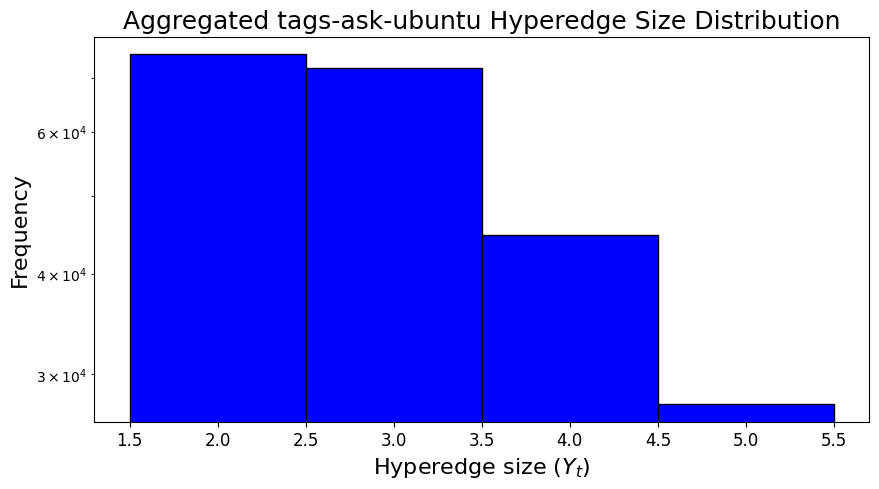

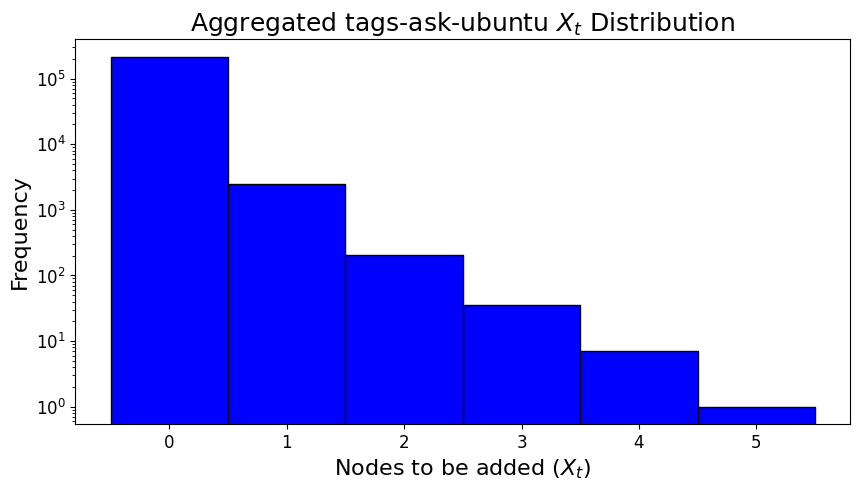

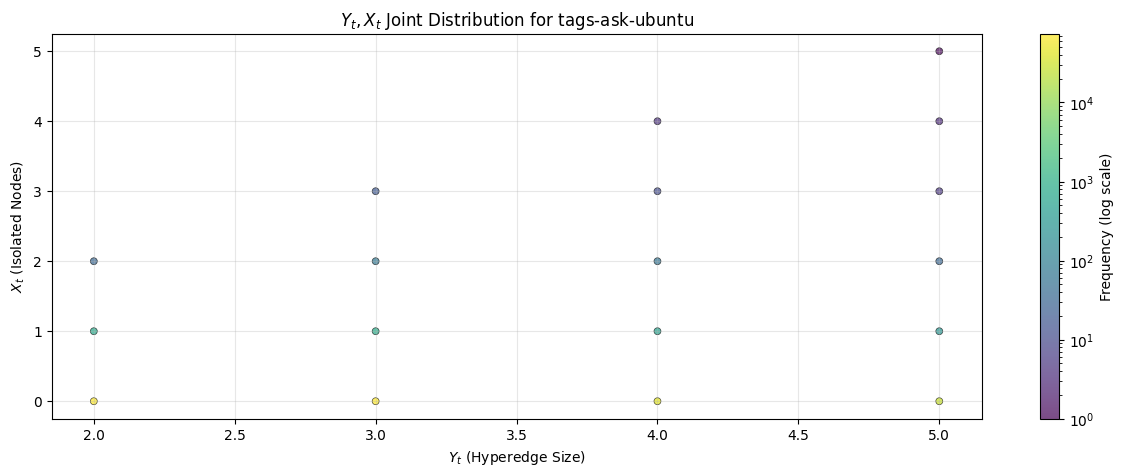

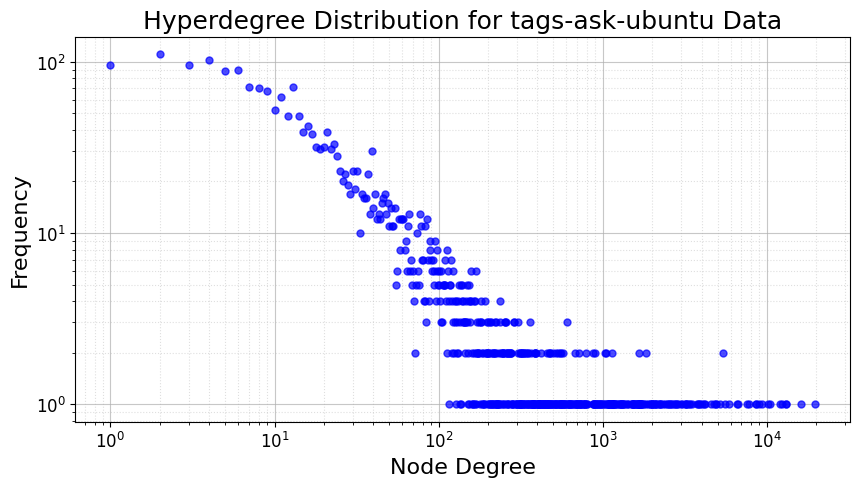

Number of nodes: 3021
Average node degree: 225.7977490897054
Number of edges: 219076
Average edge size: 3.113691139148058


In [ ]:
name = "tags-ask-ubuntu"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
tags_ubuntu_SF, tags_ubuntu_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("tags-ask-ubuntu Simplicial Fraction: "+str(tags_ubuntu_SF))

100%|██████████| 145053/145053 [00:00<00:00, 936390.59it/s]


tags-ask-ubuntu Simplicial Fraction: 0.15149467561903948


Removing singletons
The hypergraph has 1627 nodes and 558272 timestamped hyperedges
The hypergraph has 169259 unique hyperedges
Number of components: 1
Size of largest component: 1627


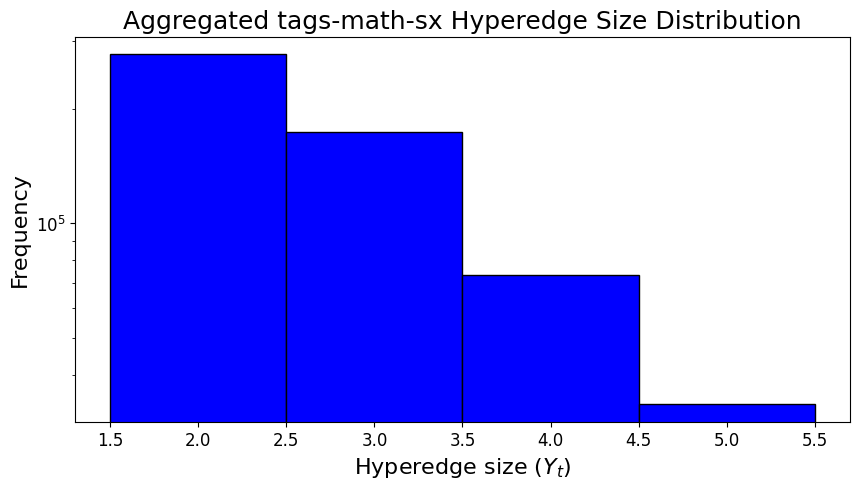

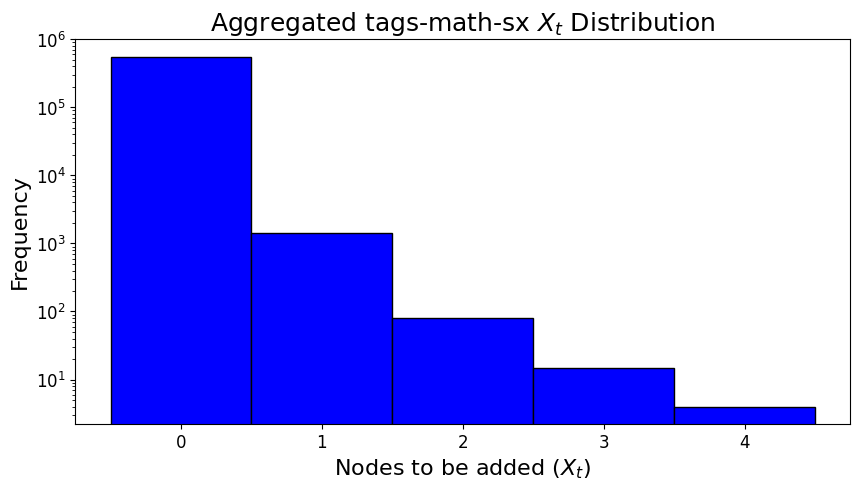

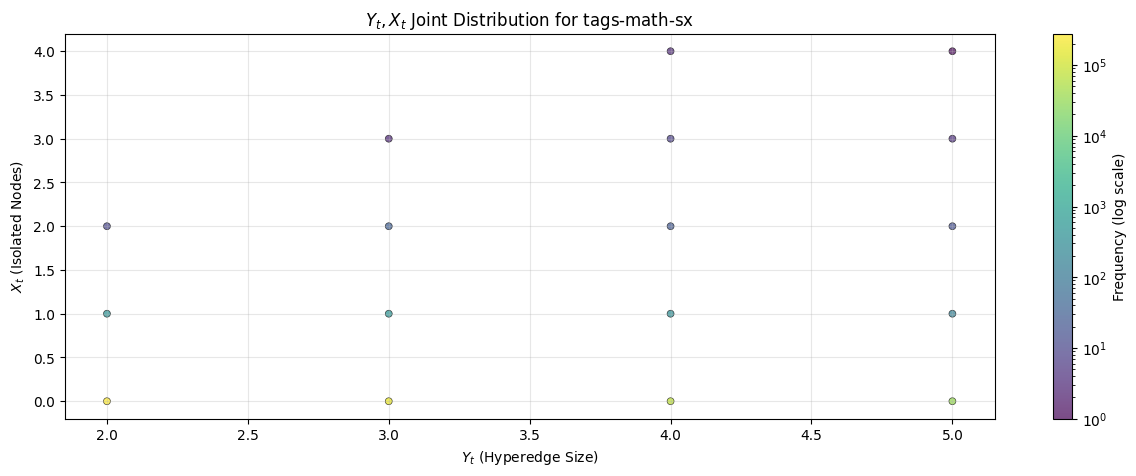

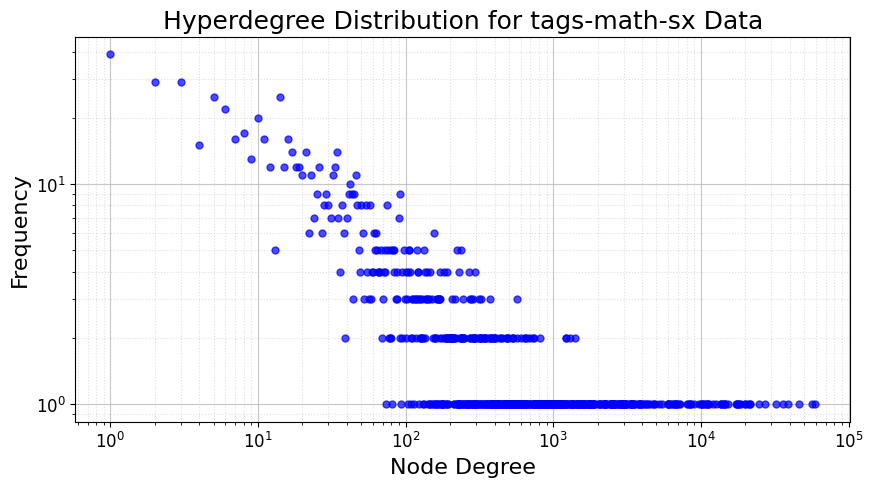

Number of nodes: 1627
Average node degree: 945.2059004302397
Number of edges: 558272
Average edge size: 2.754660810500974


In [ ]:
name = "tags-math-sx"
H = xgi.load_xgi_data(name)

print("Removing singletons")
H = H.cleanup(
    multiedges=True, singletons=False, isolates=True, relabel=False, in_place=True
    )
print(f"The hypergraph has {H.num_nodes} nodes and {H.num_edges} timestamped hyperedges")
H_cleaned = H.cleanup(
    multiedges=False, singletons=True, isolates=True, relabel=True, in_place=False
)
print(f"The hypergraph has {H_cleaned.num_edges} unique hyperedges")
max_size, sizes = Components(H, name)
print(f"Number of components: {len(sizes)}")
print(f"Size of largest component: {max_size}")

loaddata = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'+str(name)+'.pkl'
with gzip.open(loaddata, 'rb') as f:
  extracted_info = pickle.load(f)
Xt = []; Yt = []
for entry in extracted_info:
  Yt.append(entry['edge_size'])
  Xt.append(entry['isolated_nodes'])

_ = Plot_Yt(Yt, name)
_ = Plot_Xt(Xt, name)
_ = PlotJoint_XtYt(Xt, Yt, name)
_, avg_deg = DegreeDist(H, name)

print(f"Number of nodes: {sum(Xt)}")
print(f"Average node degree: {avg_deg}")
print(f"Number of edges: {len(Yt)}")
print(f"Average edge size: {sum(Yt)/len(Yt)}")

In [ ]:
H = {i: e for i, e in enumerate(H_cleaned.edges.members())}
tags_math_SF, tags_math_lengths = Get_Simpliciality_SF(H, None, minDim = 2, maxDim = np.inf)
print("tags-math-sx Simplicial Fraction: "+str(tags_math_SF))

100%|██████████| 169259/169259 [00:00<00:00, 775062.26it/s]

tags-math-sx Simplicial Fraction: 0.2683846506395567


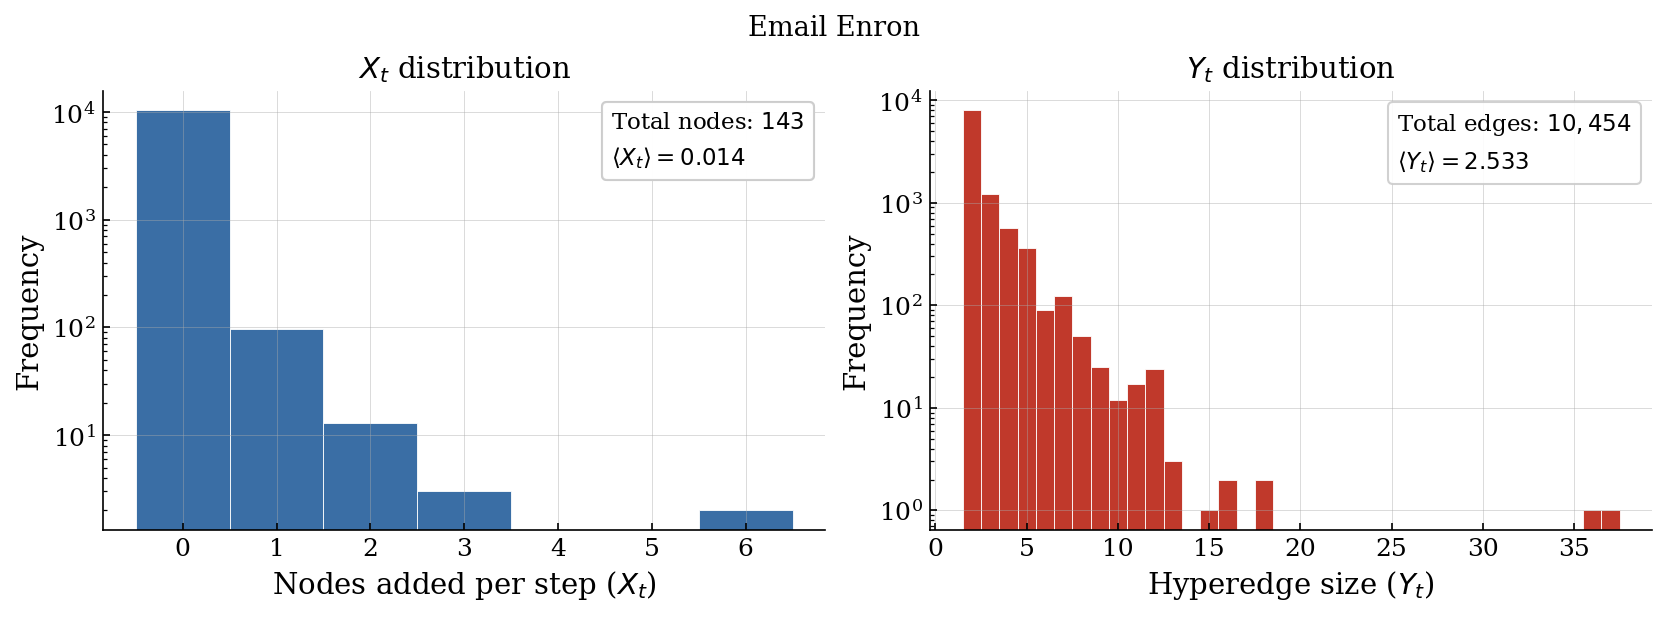

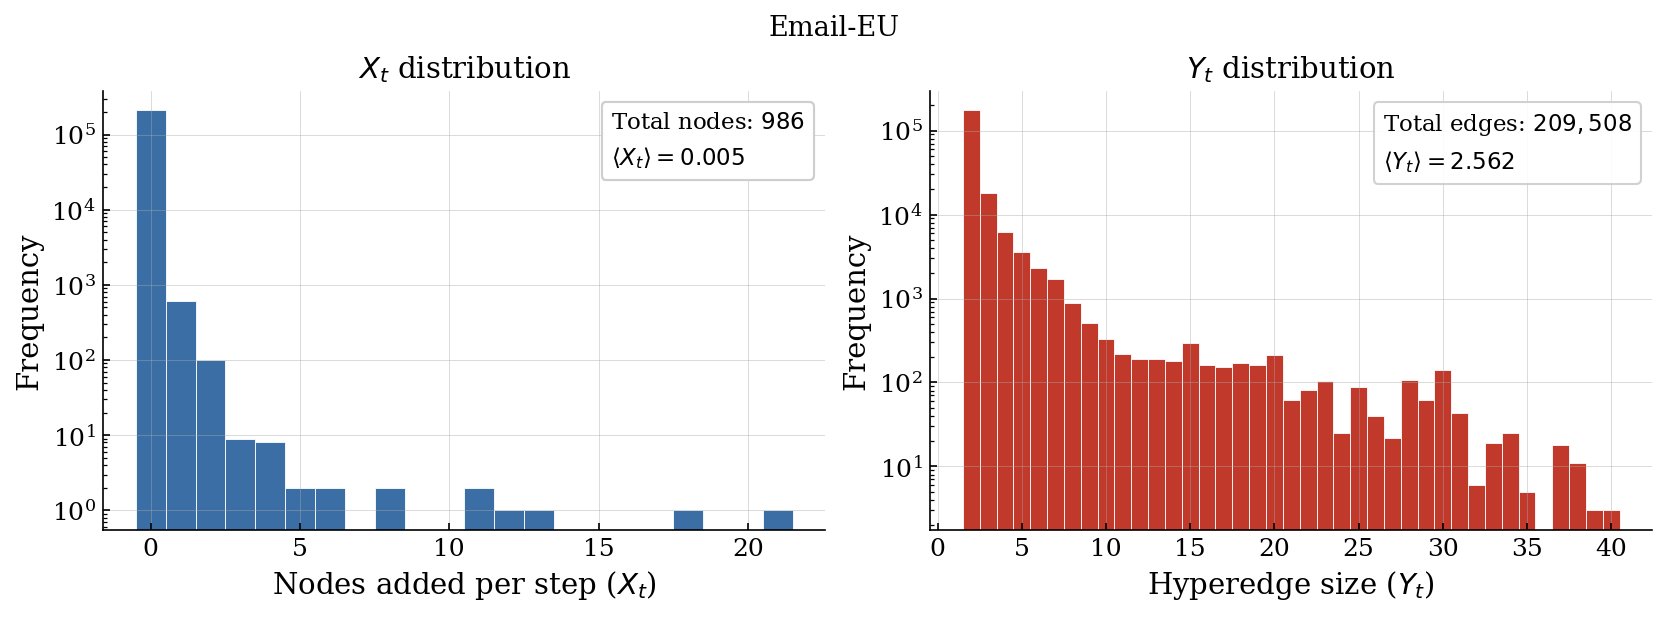

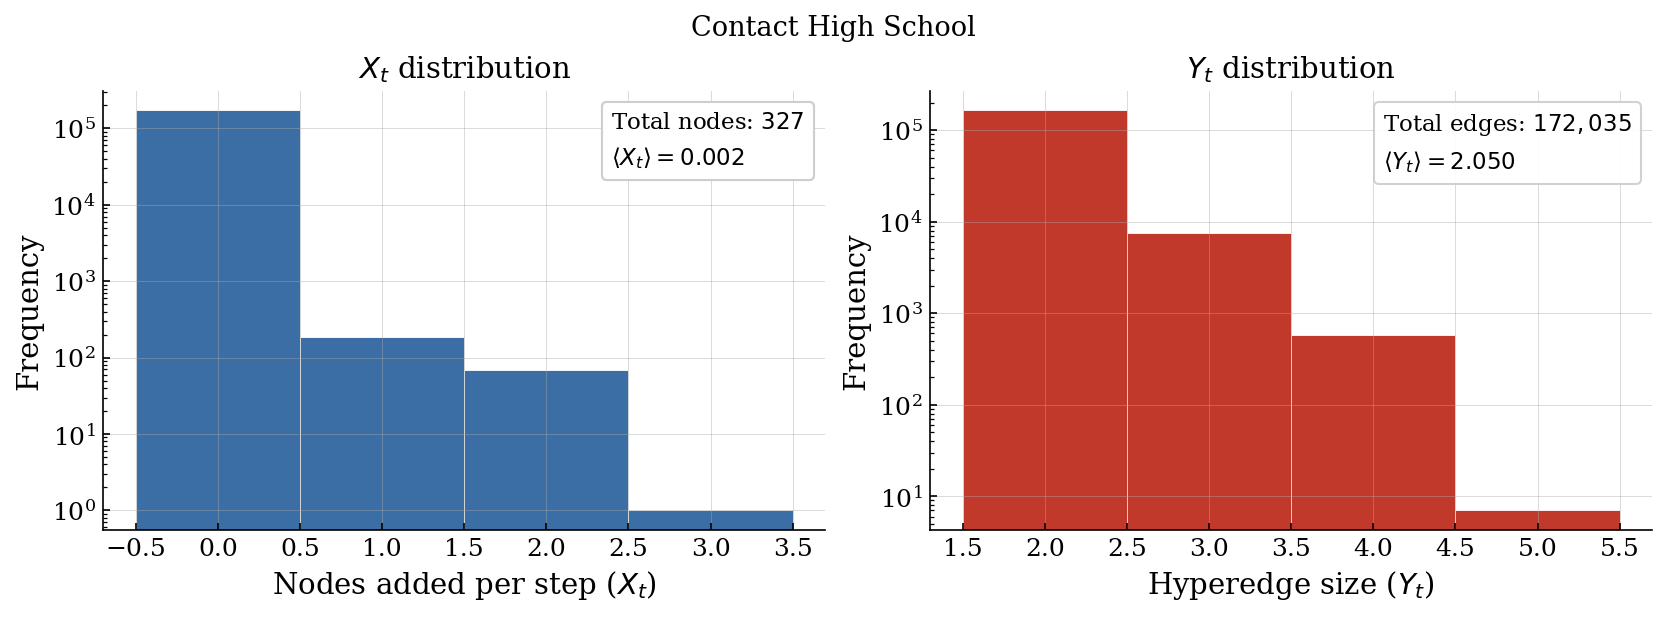

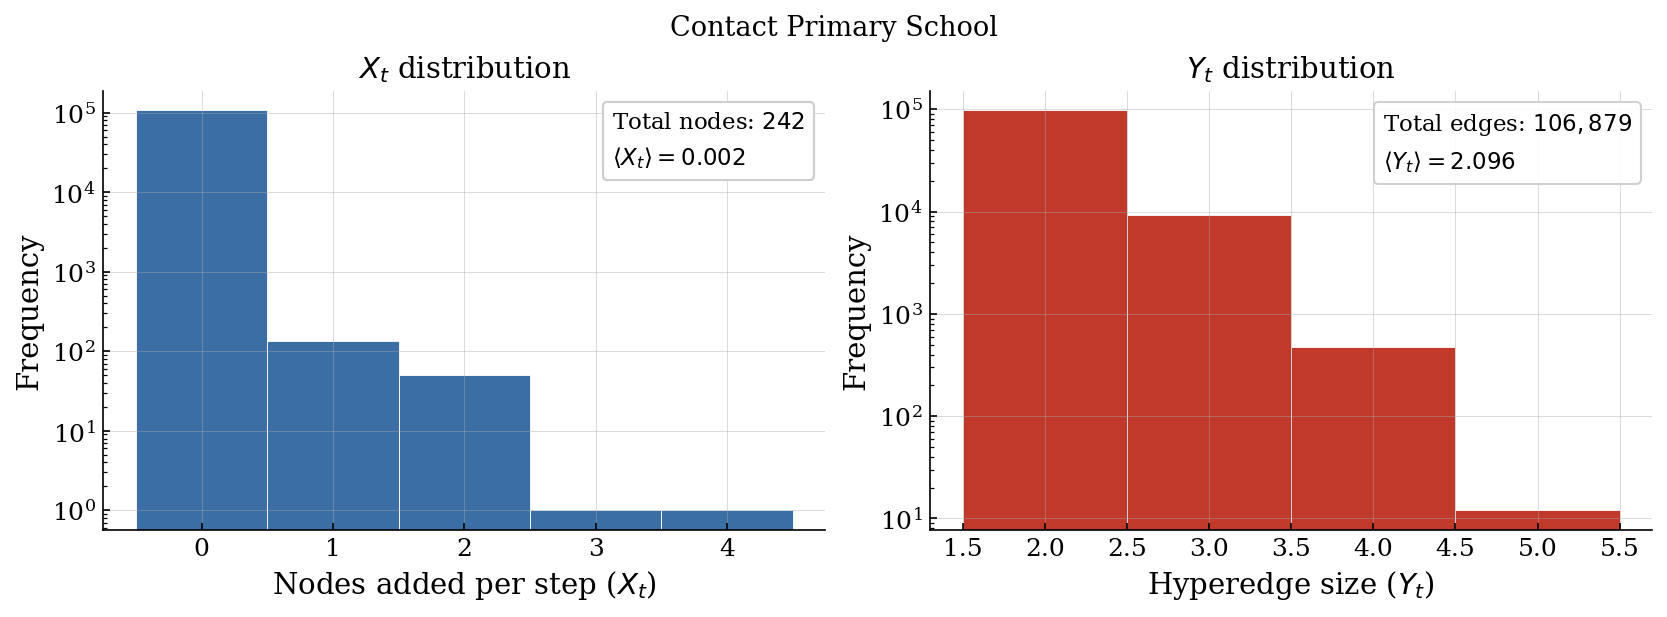

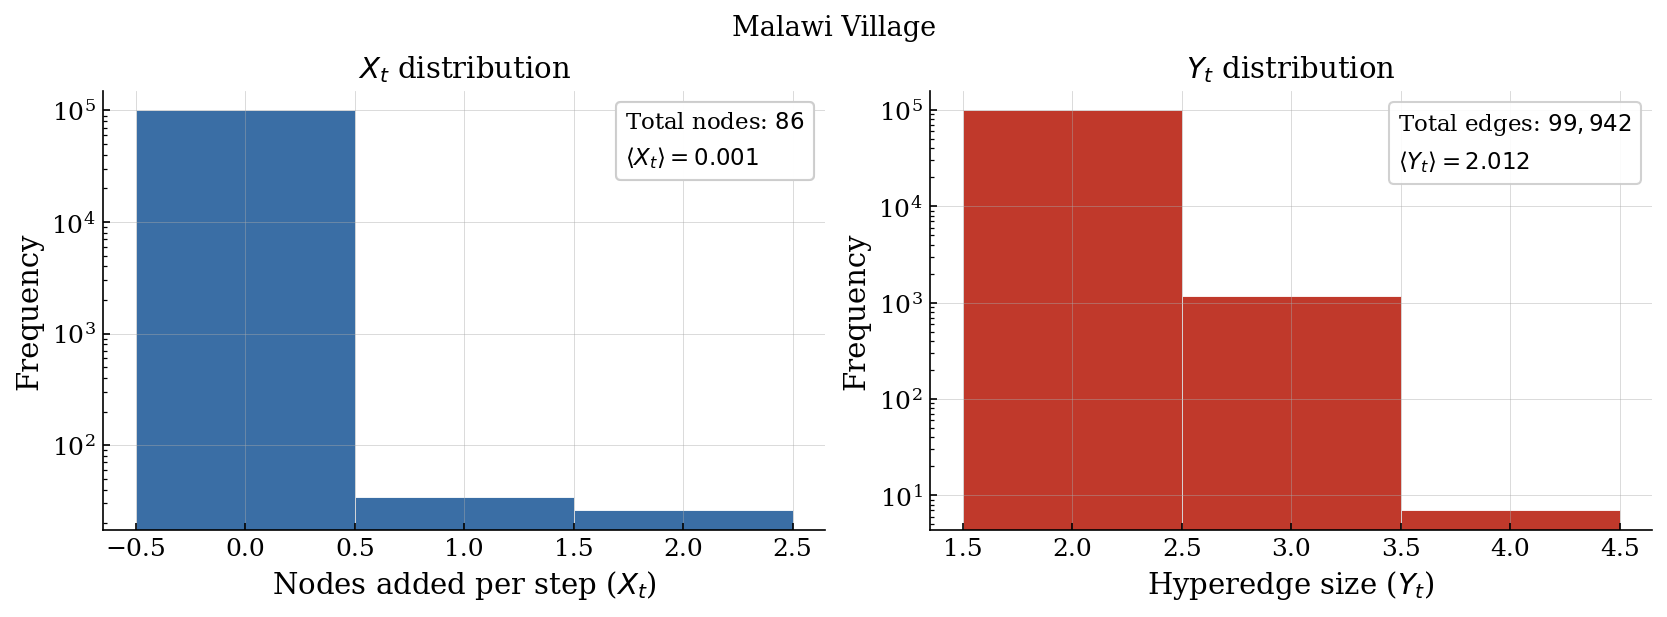

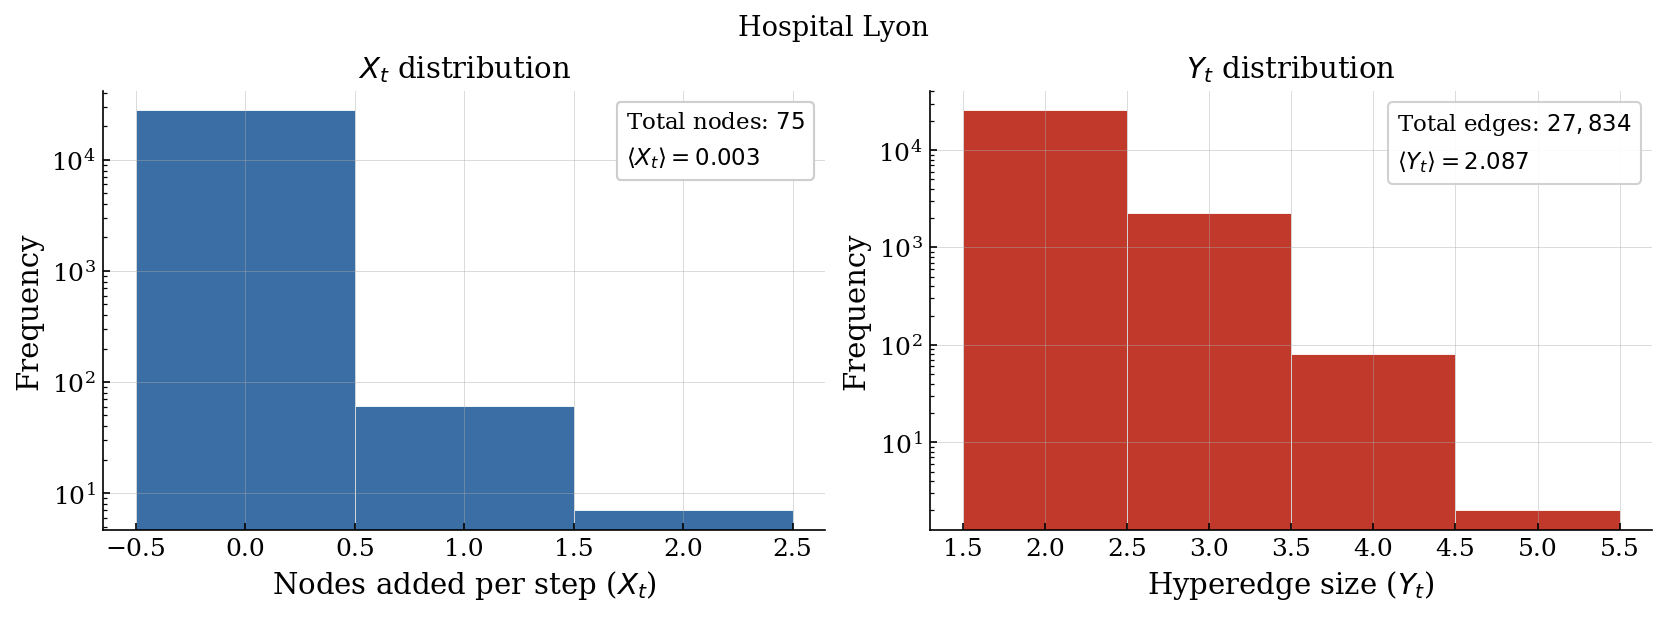

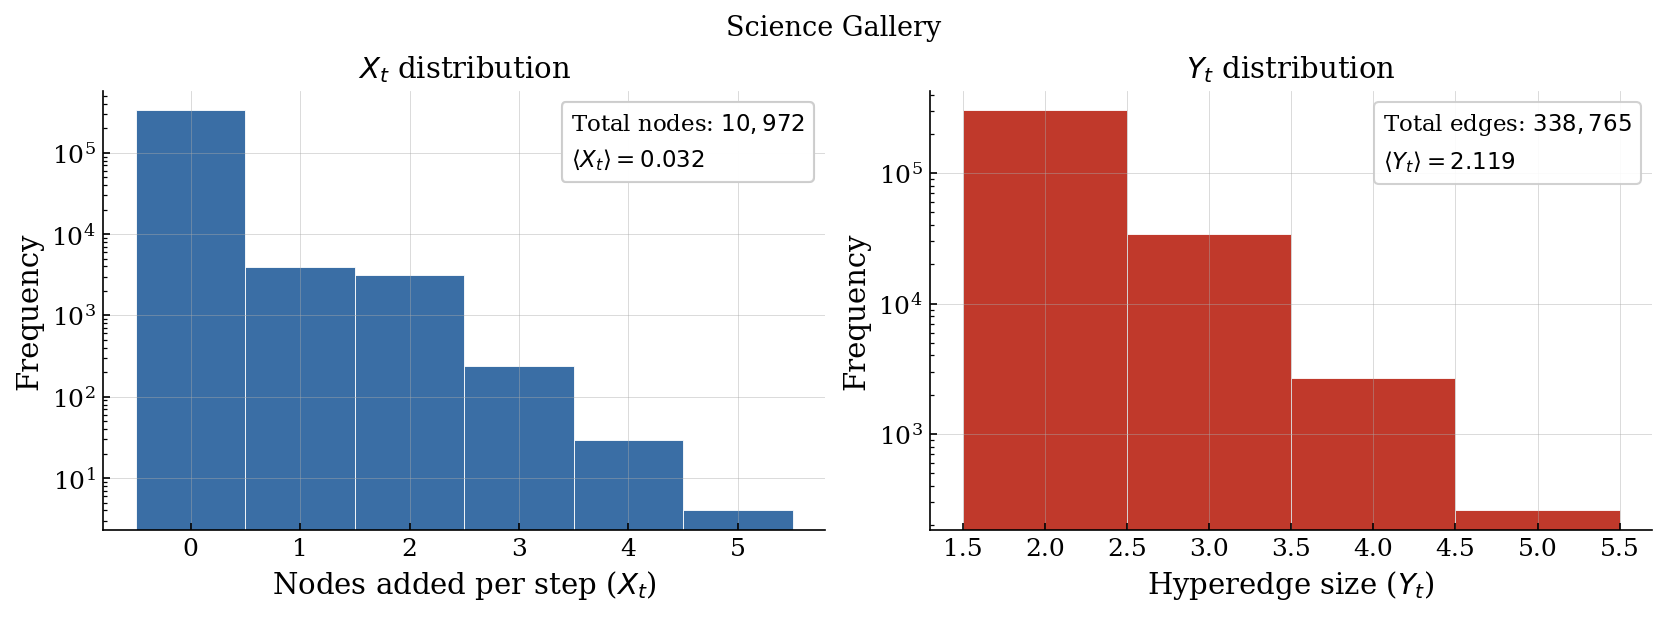

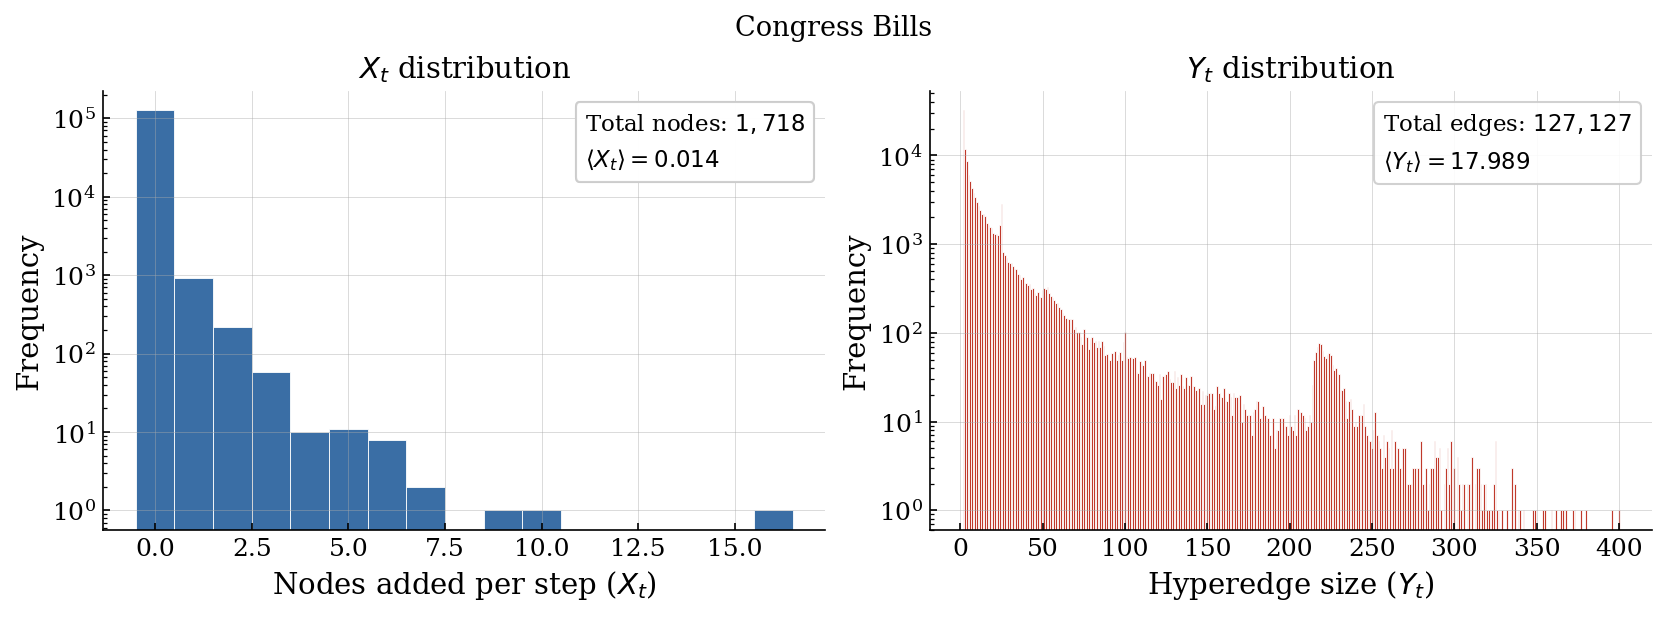

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gzip, pickle

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   11,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

names     = ['email-Enron', 'email-EU', 'contact-high-school', 'contact-primary-school',
             'malawi-village', 'hospital-lyon', 'science-gallery','congress-bills']
clean_names = ['Email Enron', 'Email-EU', 'Contact High School', 'Contact Primary School',
               'Malawi Village', 'Hospital Lyon', 'Science Gallery', 'Congress Bills']
load_base = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'

xt_color = '#3a6ea5'
yt_color = '#c0392b'

for i, name in enumerate(names):
    # ── load ──────────────────────────────────────────────────────────────────
    with gzip.open(load_base + f'{name}.pkl', 'rb') as f:
        extracted_info = pickle.load(f)

    Xt = np.array([e['isolated_nodes'] for e in extracted_info], dtype=int)
    Yt = np.array([e['edge_size']      for e in extracted_info], dtype=int)

    # ── statistics ────────────────────────────────────────────────────────────
    n_nodes     = int(Xt.sum())
    mean_xt     = Xt.mean()
    n_edges     = len(Yt)
    mean_yt     = Yt.mean()

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    clean_name = name.replace('-', ' ').title()
    fig.suptitle(clean_names[i], fontsize=13)

    # ── left panel: Xt ────────────────────────────────────────────────────────
    ax = axes[0]
    bins_xt = np.arange(Xt.min() - 0.5, Xt.max() + 1.5, 1)
    ax.hist(Xt, bins=bins_xt, color=xt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Nodes added per step ($X_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$X_t$ distribution')

    xt_legend = ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total nodes: ${n_nodes:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle X_t \rangle = {mean_xt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )
    ax.add_artist(xt_legend)

    # ── right panel: Yt ───────────────────────────────────────────────────────
    ax = axes[1]
    bins_yt = np.arange(Yt.min() - 0.5, Yt.max() + 1.5, 1)
    ax.hist(Yt, bins=bins_yt, color=yt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Hyperedge size ($Y_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$Y_t$ distribution')

    ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total edges: ${n_edges:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle Y_t \rangle = {mean_yt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )

    # ── save ──────────────────────────────────────────────────────────────────
    plt.show()

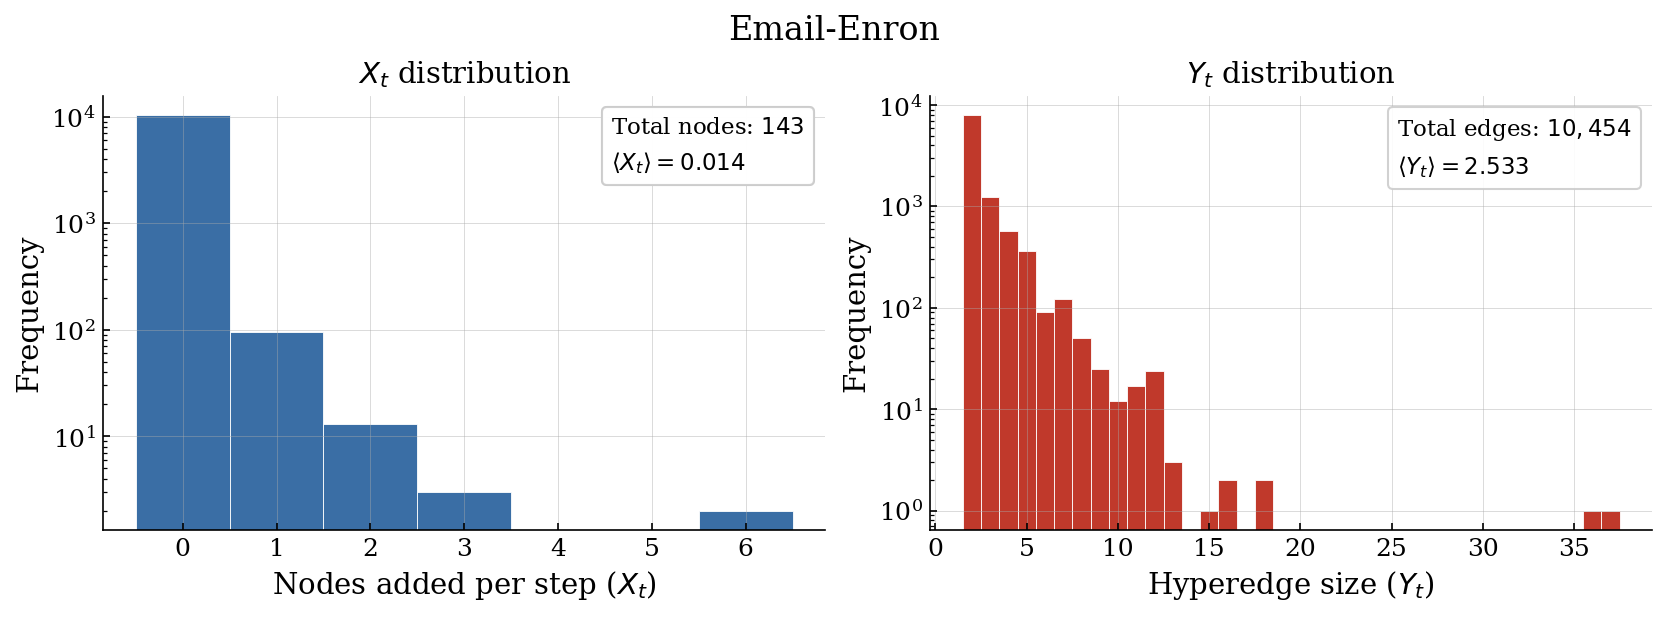

Saved: email-Enron


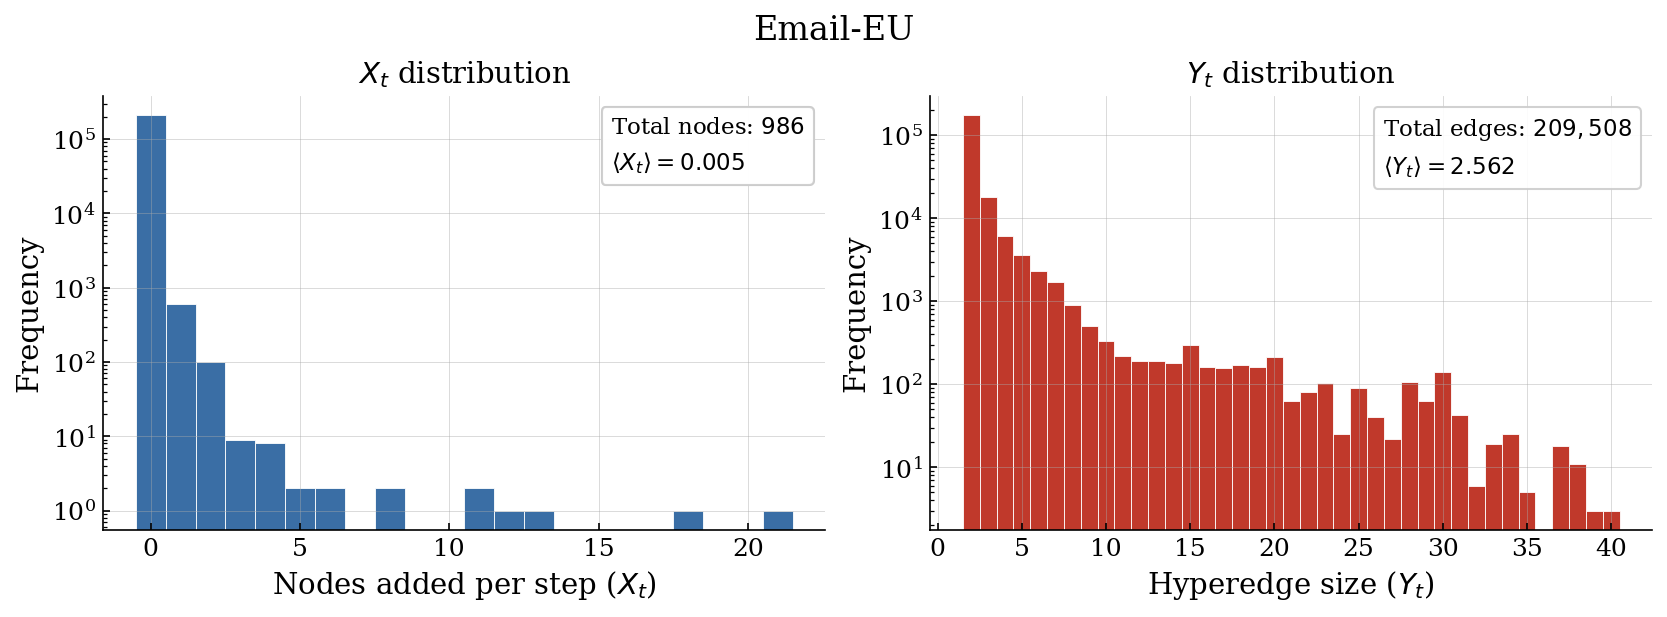

Saved: email-EU


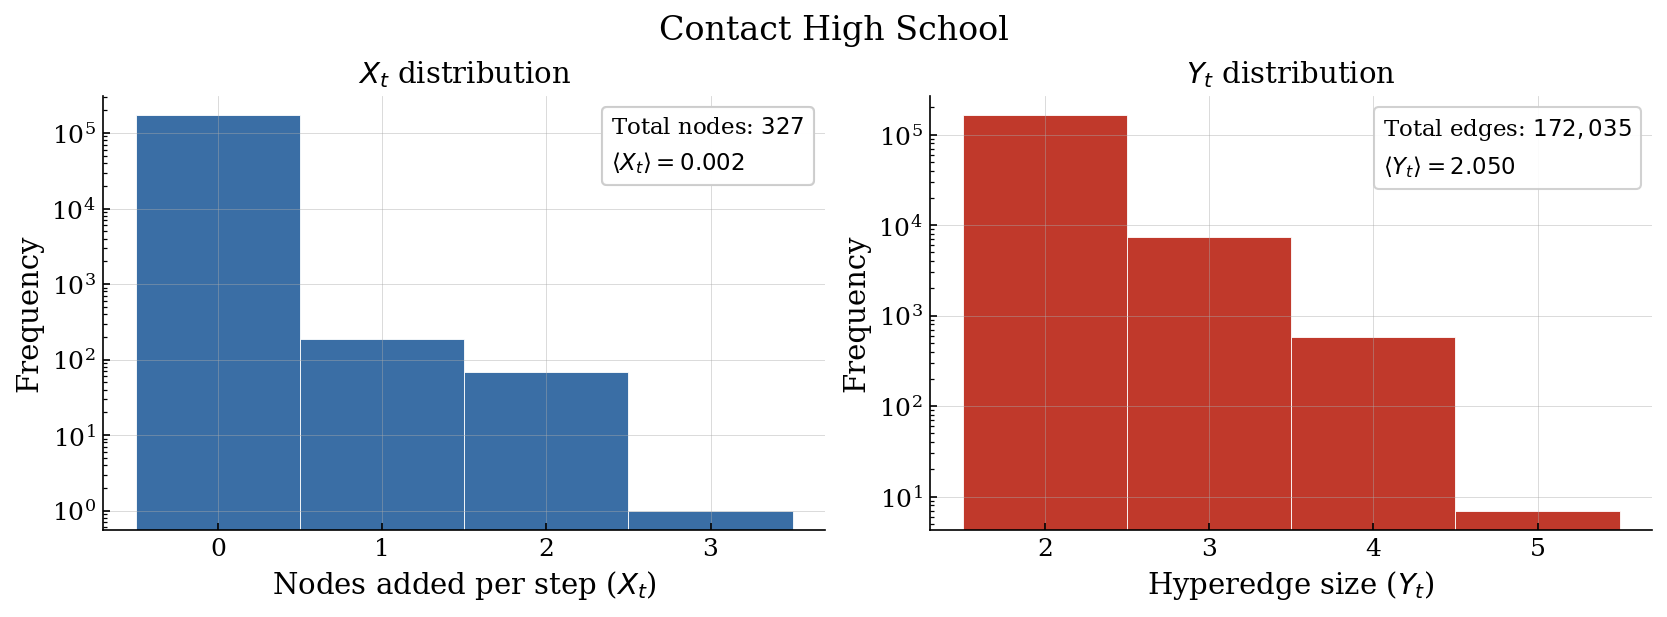

Saved: contact-high-school


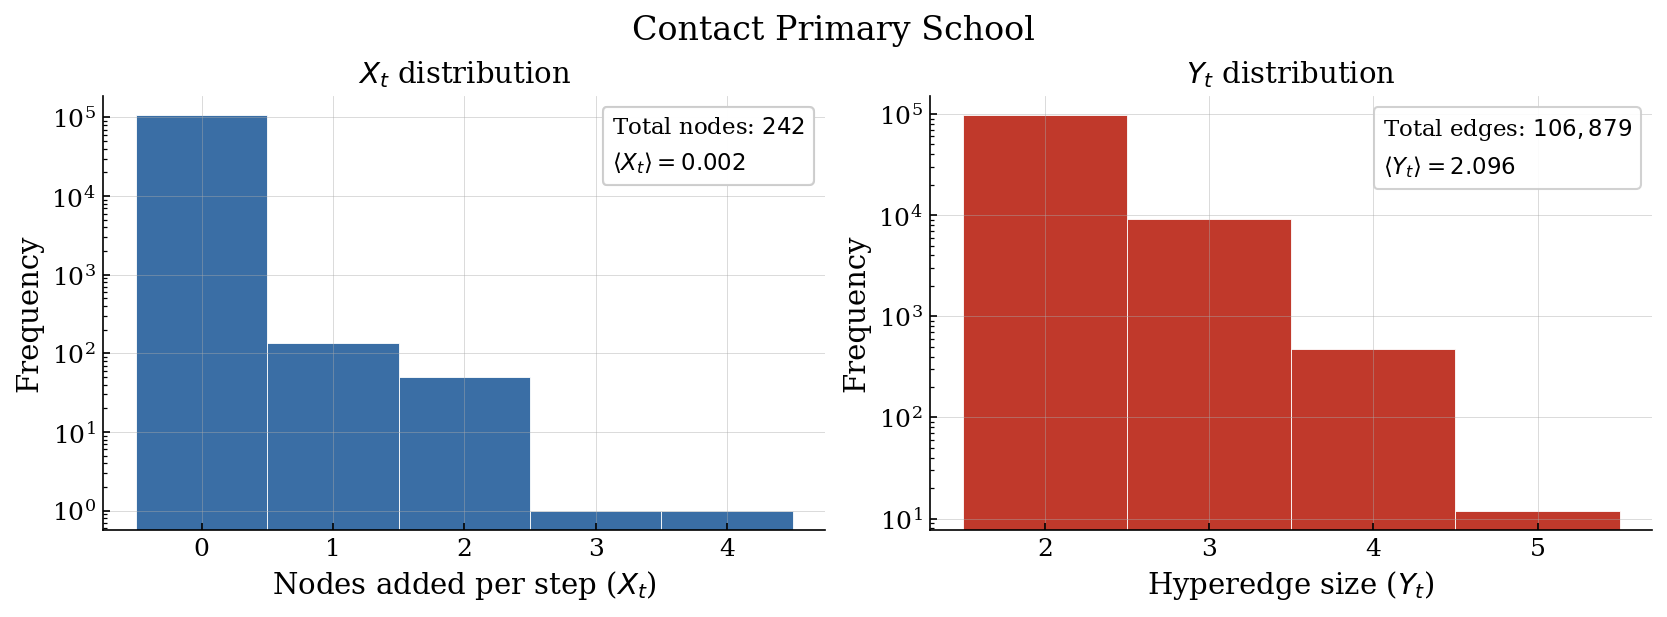

Saved: contact-primary-school


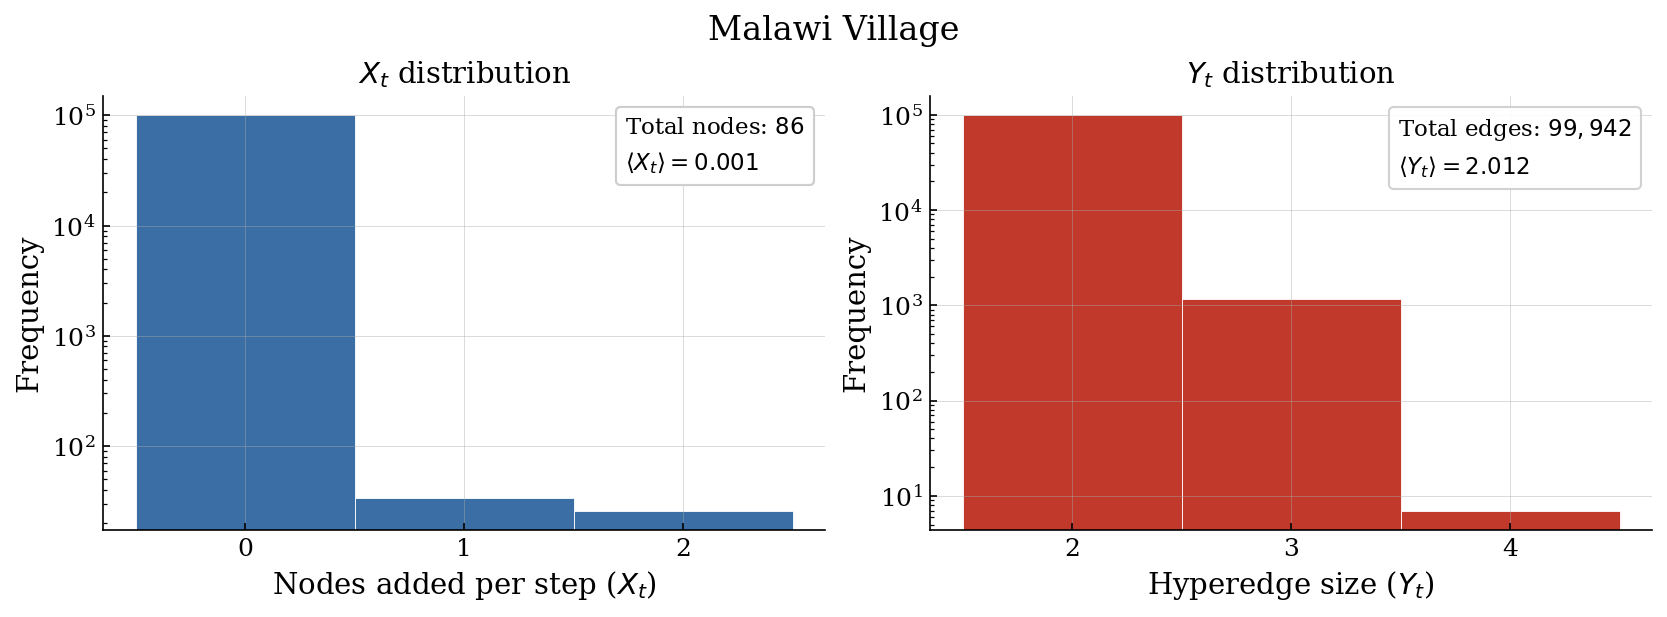

Saved: malawi-village


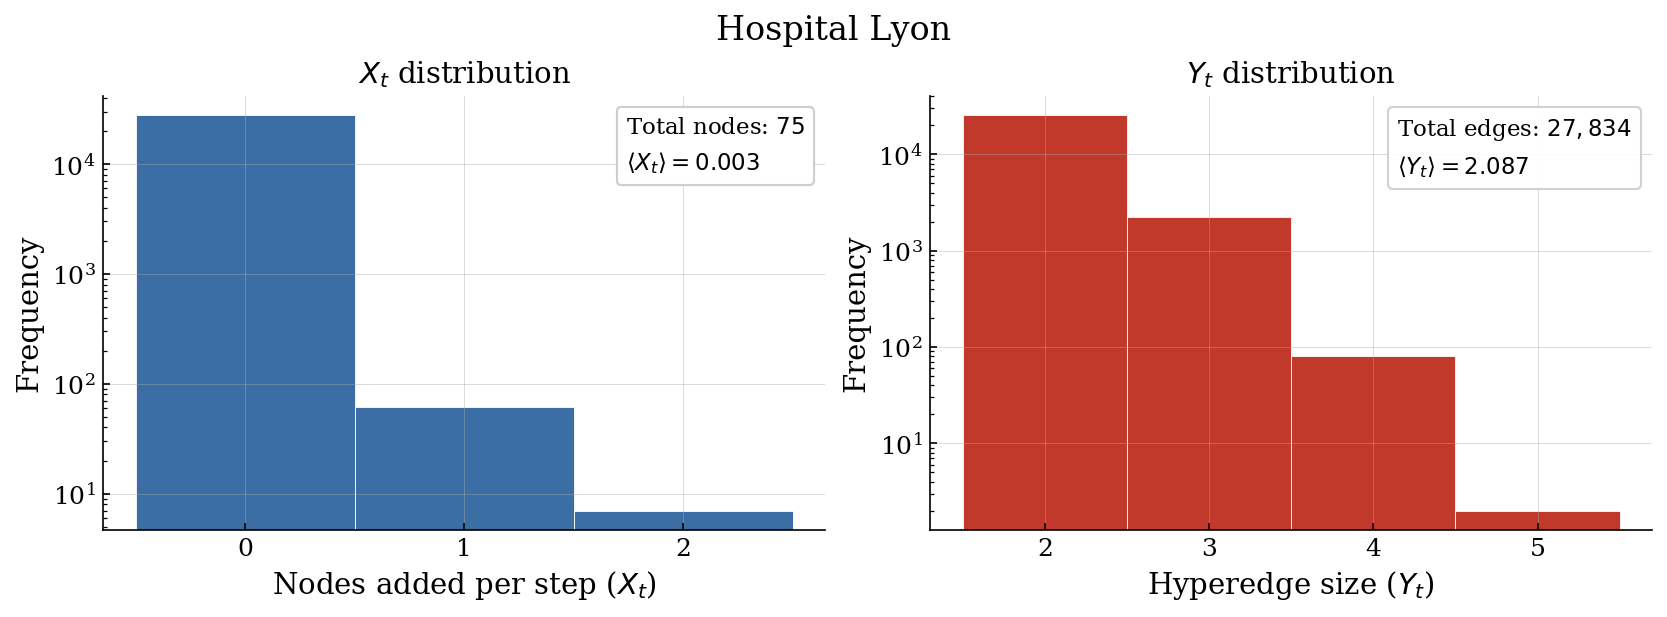

Saved: hospital-lyon


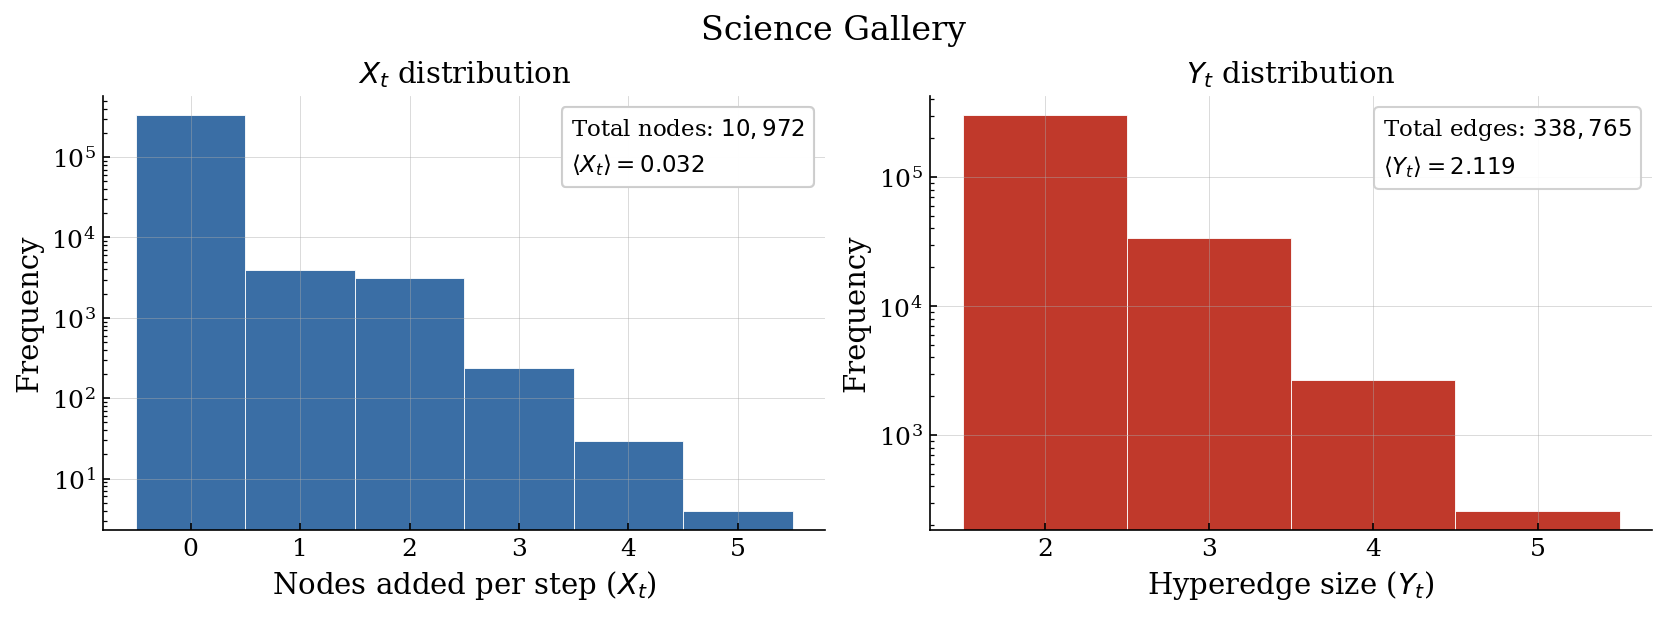

Saved: science-gallery


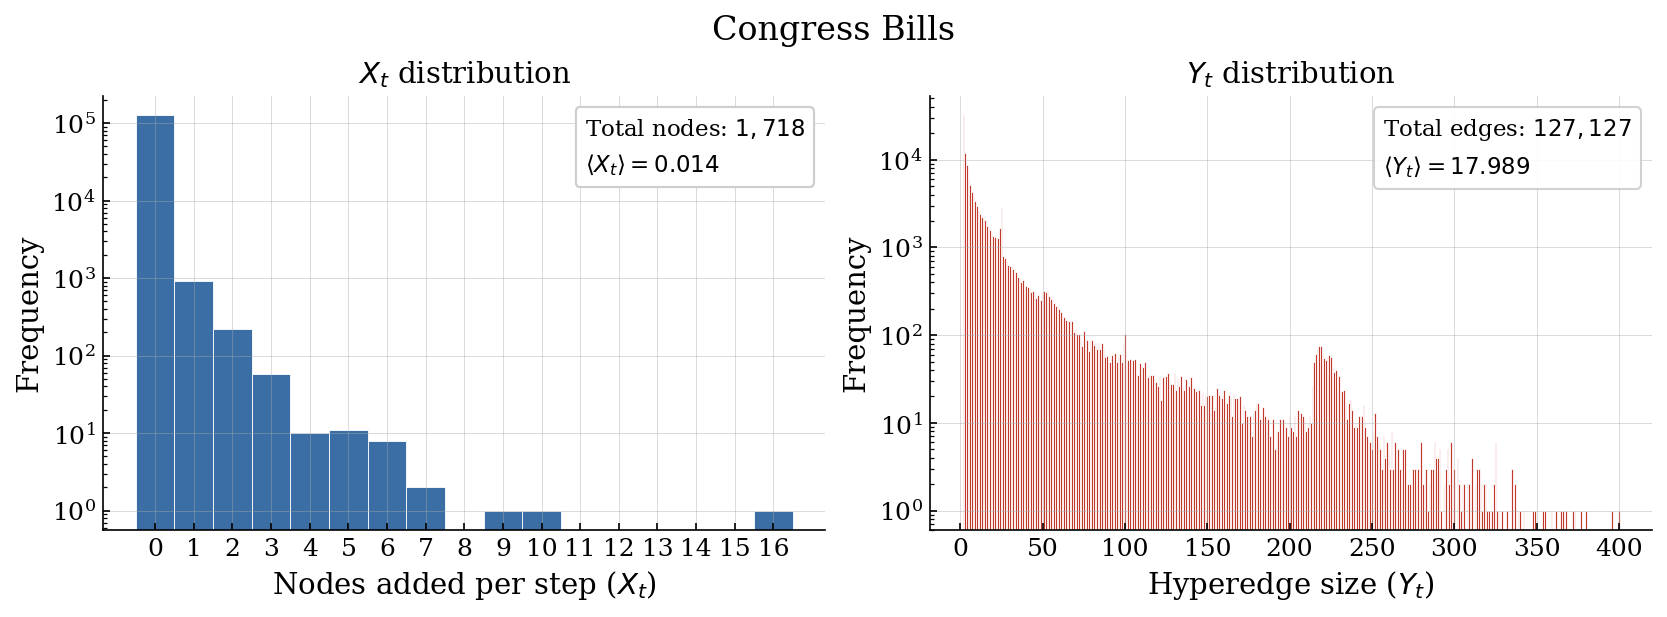

Saved: congress-bills


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gzip, pickle

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   11,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

names     = ['email-Enron', 'email-EU', 'contact-high-school', 'contact-primary-school',
             'malawi-village', 'hospital-lyon', 'science-gallery','congress-bills']
clean_names = ['Email-Enron', 'Email-EU', 'Contact High School', 'Contact Primary School',
               'Malawi Village', 'Hospital Lyon', 'Science Gallery', 'Congress Bills']
load_base = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/'
save_base = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/XtYt_FromData/Figures/'

xt_color = '#3a6ea5'
yt_color = '#c0392b'

for i, name in enumerate(names):
    # ── load ──────────────────────────────────────────────────────────────────
    with gzip.open(load_base + f'{name}.pkl', 'rb') as f:
        extracted_info = pickle.load(f)

    Xt = np.array([e['isolated_nodes'] for e in extracted_info], dtype=int)
    Yt = np.array([e['edge_size']      for e in extracted_info], dtype=int)

    # ── statistics ────────────────────────────────────────────────────────────
    n_nodes     = int(Xt.sum())
    mean_xt     = Xt.mean()
    n_edges     = len(Yt)
    mean_yt     = Yt.mean()

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    clean_name = name.replace('-', ' ').title()
    fig.suptitle(clean_names[i], fontsize=16)

    # ── left panel: Xt ────────────────────────────────────────────────────────
    ax = axes[0]
    bins_xt = np.arange(Xt.min() - 0.5, Xt.max() + 1.5, 1)
    ax.hist(Xt, bins=bins_xt, color=xt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Nodes added per step ($X_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$X_t$ distribution')
    if Xt.max() < 20:
      ax.set_xticks(np.arange(Xt.min(), Xt.max() + 1, 1))

    xt_legend = ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total nodes: ${n_nodes:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle X_t \rangle = {mean_xt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )
    ax.add_artist(xt_legend)

    # ── right panel: Yt ───────────────────────────────────────────────────────
    ax = axes[1]
    bins_yt = np.arange(Yt.min() - 0.5, Yt.max() + 1.5, 1)
    ax.hist(Yt, bins=bins_yt, color=yt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Hyperedge size ($Y_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$Y_t$ distribution')
    if Yt.max() < 20:
      ax.set_xticks(np.arange(Yt.min(), Yt.max() + 1, 1))

    ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total edges: ${n_edges:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle Y_t \rangle = {mean_yt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )

    # ── save ──────────────────────────────────────────────────────────────────
    plt.show()
    print(f'Saved: {name}')